# Thesis batch-experiment analysis

Consumes the four `*_batch_*.csv` files produced by `ExperimentRunner` and renders thesis figures.

Auto-picks the newest batch timestamp in ExperimentResults/. Override `BATCH_DIR` / `BATCH_TIMESTAMP` below.

In [1]:
import os, glob, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Print-friendly defaults for thesis figures (Phase A.2 - matplotlib).
sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'legend.frameon':    False,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'figure.dpi':        110,
})

BATCH_DIR = Path('..') / 'My project' / 'ExperimentResults'
BATCH_TIMESTAMP = None  # e.g. '2026-04-23_14-22-05'; None = newest on disk
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
TEX_DIR = Path('tables');  TEX_DIR.mkdir(exist_ok=True)

# Internal condition names (match the CSV column values - do not change).
CONDITION_ORDER = ['PureBOIDS', 'BOIDSWithGOAPLeader', 'GOAPWithBOIDSMovement']

# Phase A.1 - display labels for figures/tables. Internal names stay unchanged so
# all groupby/merge/filter joins keep working; only what the reader sees is mapped.
LABEL_MAP = {
    'PureBOIDS':             'Pure BOIDS',
    'BOIDSWithGOAPLeader':   'BOIDS + GOAP Leader',
    'GOAPWithBOIDSMovement': 'GOAP + BOIDS Movement',
}
PRETTY_ORDER   = [LABEL_MAP[c] for c in CONDITION_ORDER]
PALETTE        = dict(zip(CONDITION_ORDER, sns.color_palette('Set2', n_colors=3)))
PRETTY_PALETTE = {LABEL_MAP[k]: v for k, v in PALETTE.items()}


def prettify(target):
    """Apply LABEL_MAP to legend + x-tick text on an Axes, Figure, or FacetGrid.

    Call after the figure is built and before savefig. No-op on axes that don't
    have condition names in their legend or ticks. Safe to call multiple times.
    """
    axes = []
    if isinstance(target, matplotlib.axes.Axes):
        axes = [target]
    elif isinstance(target, matplotlib.figure.Figure):
        axes = list(target.axes)
    elif hasattr(target, 'axes'):  # seaborn FacetGrid
        flat = target.axes.flatten() if hasattr(target.axes, 'flatten') else list(target.axes)
        axes = list(flat)
        leg = getattr(target, 'legend', None)
        if leg is not None and hasattr(leg, 'get_texts'):
            for txt in leg.get_texts():
                if txt.get_text() in LABEL_MAP:
                    txt.set_text(LABEL_MAP[txt.get_text()])
    for ax in axes:
        leg = ax.get_legend()
        if leg is not None:
            for txt in leg.get_texts():
                if txt.get_text() in LABEL_MAP:
                    txt.set_text(LABEL_MAP[txt.get_text()])
        labels = [t.get_text() for t in ax.get_xticklabels()]
        if any(l in LABEL_MAP for l in labels):
            ax.set_xticklabels([LABEL_MAP.get(l, l) for l in labels])


In [2]:
def _resolve_timestamp():
    if BATCH_TIMESTAMP:
        return BATCH_TIMESTAMP
    files = glob.glob(str(BATCH_DIR / 'TrialSummary_batch_*.csv'))
    if not files:
        raise FileNotFoundError(f'No TrialSummary_batch_*.csv in {BATCH_DIR}')
    newest = max(files, key=os.path.getmtime)
    m = re.search(r'TrialSummary_batch_(.+)\.csv$', newest)
    return m.group(1)

TS = _resolve_timestamp()
print(f'Loading batch timestamp: {TS}')

def _load(prefix):
    return pd.read_csv(BATCH_DIR / f'{prefix}_batch_{TS}.csv')

def _load_eventlog():
    path = BATCH_DIR / f'EventLog_batch_{TS}.csv'
    cols = ['Time','Condition','RunId','Seed','EventType','AgentName','FlockId','Details']
    with open(path, 'r', encoding='utf-8') as f:
        next(f)
        rows = [ln.rstrip().split(',', 7) for ln in f if ln.strip()]
    df = pd.DataFrame(rows, columns=cols)
    df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
    for c in ('RunId','Seed','FlockId'):
        df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')
    return df

trials = _load('TrialSummary')
perf   = _load('Performance')
goals  = _load('GoalDistribution')
events = _load_eventlog()

for name, df in [('trials', trials), ('perf', perf), ('goals', goals), ('events', events)]:
    print(f'{name}: {len(df):>7} rows, cols={list(df.columns)}')

trials['Condition']   = pd.Categorical(trials['Condition'],   categories=CONDITION_ORDER, ordered=True)
perf['Condition']     = pd.Categorical(perf['Condition'],     categories=CONDITION_ORDER, ordered=True)
goals['Condition']    = pd.Categorical(goals['Condition'],    categories=CONDITION_ORDER, ordered=True)
trials.head()


Loading batch timestamp: 2026-05-05_02-43-09


trials:     600 rows, cols=['BenchmarkMode', 'Condition', 'AgentCount', 'RunId', 'Seed', 'Outcome', 'DurationSec', 'ReactionMeleeMs', 'ReactionRangedMs', 'GoalEntropy', 'AvgFPS', 'AvgCpuMs', 'AvgCpuMsPerAgent', 'MaxAgentCount', 'AvgGcMemoryMB', 'AvgMonoUsedMB', 'AvgTotalAllocatedMB', 'TotalDamageToPlayer', 'DamagePerSecondToPlayer', 'FirstHitMs', 'AgentsKilledByPlayer']
perf: 8020769 rows, cols=['Frame', 'Time', 'BenchmarkMode', 'Condition', 'RunId', 'Seed', 'FPS', 'AvgFPS', 'AgentCount', 'CPUTimeMs', 'CPUTimeMsPerAgent', 'GcMemoryMB', 'MonoUsedMB', 'TotalAllocatedMB']
goals:   75658 rows, cols=['Time', 'BenchmarkMode', 'Condition', 'RunId', 'Seed', 'TotalAgents', 'FlockCoherence', 'Attack', 'RangedAttack', 'Flee', 'Scatter', 'Regroup', 'Flank', 'Guard', 'Wander', 'Kite']
events: 1812914 rows, cols=['Time', 'Condition', 'RunId', 'Seed', 'EventType', 'AgentName', 'FlockId', 'Details']


,BenchmarkMode,Condition,AgentCount,RunId,Seed,Outcome,DurationSec,ReactionMeleeMs,ReactionRangedMs,GoalEntropy,...,AvgCpuMs,AvgCpuMsPerAgent,MaxAgentCount,AvgGcMemoryMB,AvgMonoUsedMB,AvgTotalAllocatedMB,TotalDamageToPlayer,DamagePerSecondToPlayer,FirstHitMs,AgentsKilledByPlayer
0,Stress,PureBOIDS,50,0,42,TimeLimit,60.0,97.6,3.1,1.941,...,2.660,0.053,50,803.55,803.55,2808.49,0.0,0.0,-1.0,0
1,Stress,GOAPWithBOIDSMovement,50,0,42,TimeLimit,60.0,9.3,9.3,0.365,...,2.699,0.054,50,864.39,864.39,2819.56,0.0,0.0,-1.0,0
2,Stress,BOIDSWithGOAPLeader,50,0,42,TimeLimit,60.0,2979.1,23577.9,1.242,...,2.575,0.051,50,866.50,866.50,2829.75,0.0,0.0,-1.0,0
3,Stress,PureBOIDS,50,1,43,TimeLimit,60.0,2.2,2.0,1.613,...,2.561,0.051,50,938.96,938.96,2842.03,0.0,0.0,-1.0,0
4,Stress,GOAPWithBOIDSMovement,50,1,43,TimeLimit,60.0,5.6,5.6,0.419,...,2.710,0.054,50,1022.44,1022.44,2854.24,0.0,0.0,-1.0,0


## Warmup-trim helper

The first ~5 s of every trial is dominated by spawn/agent-init overhead. Cross-condition
FPS comparisons at high N are unfair when GOAP+BOIDS trials average ~10 s and PureBOIDS
trials average 60 s - the GOAP+BOIDS mean is dominated by warmup, the PureBOIDS mean
is dominated by steady state. The cell below computes warmup-trimmed AvgFPS/AvgCpuMs
per trial (falls back to raw values for trials shorter than the warmup) and merges them
into `trials` as `*_trimmed` columns. Use these for the steady-state RQ1 comparison;
keep the originals for documenting the absolute frame budget.

In [3]:
WARMUP_SEC = 5.0

# IMPORTANT — schema note:
# Performance_batch_*.csv has `AgentCount` as the LIVE per-frame count (drops as
# agents despawn via pooled HP). TrialSummary_batch_*.csv has `AgentCount` as the
# CONFIGURED trial size (constant per trial). They are NOT the same column.
# `(Condition, Seed)` is the unique per-trial key shared by both files; use that
# to join perf rows back to trials.

# Per-trial relative time (Time column is global across the batch).
perf['TrialTime'] = perf['Time'] - perf.groupby(
    ['Condition', 'Seed'], observed=True)['Time'].transform('min')

# Warmup-trimmed per-trial means.
# Performance CSV columns are CPUTimeMs/CPUTimeMsPerAgent (per-frame); TrialSummary
# uses AvgCpuMs/AvgCpuMsPerAgent (per-trial means). After per-trial averaging the
# semantics line up, so we rename to match TrialSummary's naming for clean merging.
PERF_COLS = ['AvgFPS', 'CPUTimeMs', 'CPUTimeMsPerAgent']
TRIAL_COLS = ['AvgFPS', 'AvgCpuMs', 'AvgCpuMsPerAgent']
RENAME = dict(zip(PERF_COLS, TRIAL_COLS))

trimmed = (perf[perf['TrialTime'] > WARMUP_SEC]
           .groupby(['Condition', 'Seed'], observed=True)[PERF_COLS]
           .mean()
           .rename(columns=RENAME)
           .add_suffix('_trimmed')
           .reset_index())

trials = trials.merge(trimmed, on=['Condition', 'Seed'], how='left')

# Trials shorter than the warmup contribute nothing to the trimmed mean - fall back
# to the raw value so summary tables don't get NaNs and short trials still appear.
short_trials = 0
for c in TRIAL_COLS:
    short_trials += int(trials[f'{c}_trimmed'].isna().sum())
    trials[f'{c}_trimmed'] = trials[f'{c}_trimmed'].fillna(trials[c])

print(f'Warmup trim = {WARMUP_SEC}s. {short_trials // len(TRIAL_COLS)} '
      f'trial(s) shorter than warmup - fell back to raw AvgFPS/CPU.')
trials[['Condition', 'AgentCount', 'AvgFPS', 'AvgFPS_trimmed']].head()


Warmup trim = 5.0s. 0 trial(s) shorter than warmup - fell back to raw AvgFPS/CPU.


,Condition,AgentCount,AvgFPS,AvgFPS_trimmed
0,PureBOIDS,50,406.9,427.294300
1,GOAPWithBOIDSMovement,50,395.1,409.422620
2,BOIDSWithGOAPLeader,50,413.9,427.952755
3,PureBOIDS,50,416.1,428.905953
4,GOAPWithBOIDSMovement,50,393.1,409.830429


## 0 — Live-agent-count artifact diagnostic (item 3a)

> **Why this section runs before all figures.** The v1 RQ1 narrative — that BOIDSWithGOAPLeader is faster than PureBOIDS at high N (median 483 FPS vs 121 at N=800) — may be an artifact of agents dying faster (pooled HP drains → fewer live entities → less per-frame compute), not an architectural advantage. I want to confirm this before building any further results on top of the v1 numbers.

The diagnostic runs in three sub-cells:

- **3a-i** computes integrated agent-frames per trial (Σ live `AgentCount` across recorded frames). Lower = condition lost agents faster, mechanically lowering its own compute load.
- **3a-ii** bins per-frame data by live `AgentCount` and reports `FPS | live_AgentCount = N` per condition, then plots panel A (current canonical view, per-trial means by configured N) side-by-side with panel B (corrected view, FPS conditional on live N).
- **3a-iii** prints the verdict table. If panel B's gap is materially smaller than panel A's (or reverses), the v1 RQ1 narrative is contaminated and item 3b's stress-mode reruns become the canonical RQ1 result.

See [[methodology-revisions-2026-04]] item 3a for full methodology context.


In [4]:
# 3a-i: Integrated agent-frames per trial — how much total compute each condition actually had.
#
# `Performance_batch:AgentCount` is the LIVE per-frame count (drains as agents take damage and
# pooled HP culls them). A condition that kills agents faster mechanically reduces its own
# per-frame compute load. We need to know, for each trial, the integrated work the engine
# actually performed: Σ AgentCount across all recorded frames.
#
# If at the same configured N (e.g. 800), BOIDSWithGOAPLeader has materially fewer agent-frames
# than PureBOIDS, then any FPS advantage at that configured N is partly or entirely an artifact
# of agent-count decay rather than architecture.

# Quartile helpers used throughout Section 0 (Section 4b also defines these — harmless re-def).
def q25(s): return s.quantile(0.25)
def q75(s): return s.quantile(0.75)

configured_n = (trials[['Condition', 'Seed', 'AgentCount']]
                .rename(columns={'AgentCount': 'ConfiguredN'}))
perf_with_n = perf.merge(configured_n, on=['Condition', 'Seed'], how='left')

agent_frames = (perf_with_n
                .groupby(['Condition', 'ConfiguredN', 'Seed'], observed=True)
                .agg(integrated_agent_frames=('AgentCount', 'sum'),
                     frames_observed=('AgentCount', 'size'),
                     mean_live_n=('AgentCount', 'mean'),
                     final_live_n=('AgentCount', 'last'))
                .reset_index())

af_summary = (agent_frames
              .groupby(['Condition', 'ConfiguredN'], observed=True)
              .agg(integrated_agent_frames_median=('integrated_agent_frames', 'median'),
                   mean_live_n_median=('mean_live_n', 'median'),
                   final_live_n_median=('final_live_n', 'median'),
                   frames_median=('frames_observed', 'median'))
              .round(0))
print('Integrated agent-frames + mean live N + final live N (medians per cell):')
print(af_summary)

# Quick read: at each configured N, ratio of agent-frames between conditions.
af_pivot = (agent_frames.groupby(['Condition', 'ConfiguredN'], observed=True)
            ['integrated_agent_frames'].median().unstack('Condition'))
af_pivot['Leader/Pure'] = (af_pivot['BOIDSWithGOAPLeader'] / af_pivot['PureBOIDS']).round(2)
af_pivot['GOAP+BOIDS/Pure'] = (af_pivot['GOAPWithBOIDSMovement'] / af_pivot['PureBOIDS']).round(2)
print('\nIntegrated agent-frames ratios vs PureBOIDS (median per cell):')
print(af_pivot[['Leader/Pure', 'GOAP+BOIDS/Pure']])


Integrated agent-frames + mean live N + final live N (medians per cell):
                                   integrated_agent_frames_median  \
Condition             ConfiguredN                                   
PureBOIDS             50                                4677796.0   
                      100                               7723814.0   
                      200                               9760646.0   
                      400                               8902876.0   
                      800                               6243536.0   
BOIDSWithGOAPLeader   50                                4605416.0   
                      100                               7597069.0   
                      200                               9598927.0   
                      400                               8822689.0   
                      800                               6518323.0   
GOAPWithBOIDSMovement 50                                3885900.0   
                      100     

FPS | live AgentCount = N (post-warmup):
                               median     q25     q75    count
Condition             LiveBin                                 
PureBOIDS             50       426.52  415.15  445.17  2530926
                      100      335.56  321.75  367.03  1526520
                      200      189.97  180.27  209.35   938538
                      400       78.11   71.85   85.09   390512
                      800       27.10   25.56   29.41   105672
BOIDSWithGOAPLeader   50       417.87  406.98  439.96  2362412
                      100      331.75  322.25  362.75  1595672
                      200      192.45  185.70  202.43   924264
                      400       80.62   77.36   87.12   408336
                      800       29.11   28.31   32.39   121264
GOAPWithBOIDSMovement 50       398.58  389.71  425.12  2215126
                      100      296.71  285.28  308.58  1290218
                      200      163.69  157.05  170.46   696390
              

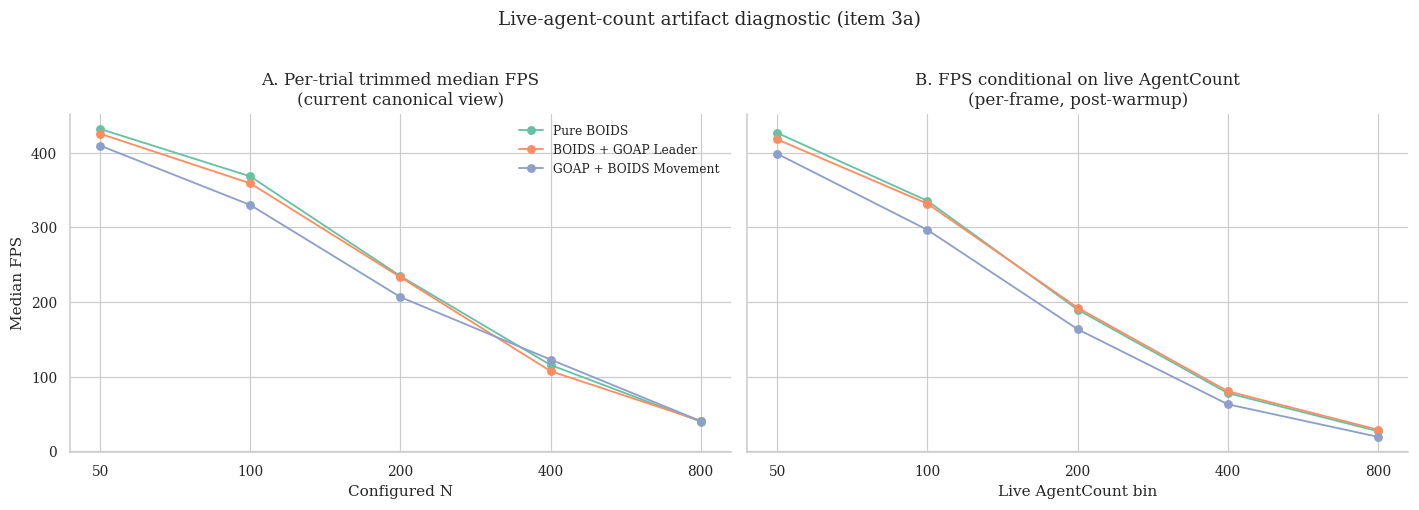

In [5]:
# 3a-ii: FPS conditional on live AgentCount (the corrected view) + side-by-side figure.
#
# Bin every per-frame perf row by its live AgentCount into the configured-N sweep buckets.
# This removes the death-rate confound: we now compare conditions at the same number of
# live entities, regardless of how the trial got there.

sweep = sorted(trials['AgentCount'].unique())
edges = [-np.inf] + [(sweep[i] + sweep[i+1]) / 2 for i in range(len(sweep)-1)] + [np.inf]
perf_with_n['LiveBin'] = pd.cut(perf_with_n['AgentCount'], bins=edges, labels=sweep,
                                 include_lowest=True)

# Apply the same warmup trim used elsewhere.
post_warmup = perf_with_n[perf_with_n['TrialTime'] > WARMUP_SEC].copy()

fps_conditional = (post_warmup.groupby(['Condition', 'LiveBin'], observed=True)['AvgFPS']
                   .agg(['median', q25, q75, 'count']).round(2))
print('FPS | live AgentCount = N (post-warmup):')
print(fps_conditional)

# Side-by-side figure: A (current canonical) vs B (corrected).
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

# A — per-trial trimmed median FPS by configured N (the figure that drives the v1 thesis claim).
left = (trials.groupby(['Condition', 'AgentCount'], observed=True)['AvgFPS_trimmed']
        .median().reset_index())
for cond in CONDITION_ORDER:
    sub = left[left['Condition'] == cond].sort_values('AgentCount')
    axes[0].plot(sub['AgentCount'], sub['AvgFPS_trimmed'], marker='o',
                 color=PALETTE[cond], label=cond)
axes[0].set_xscale('log', base=2)
axes[0].set_xticks(sweep); axes[0].set_xticklabels(sweep)
axes[0].set_xlabel('Configured N'); axes[0].set_ylabel('Median FPS')
axes[0].set_title('A. Per-trial trimmed median FPS\n(current canonical view)')
axes[0].legend(loc='best', fontsize=8)

# B — median FPS where live AgentCount = N, post-warmup (the corrected view).
right = (post_warmup.groupby(['Condition', 'LiveBin'], observed=True)['AvgFPS']
         .median().reset_index())
right['LiveBin'] = right['LiveBin'].astype(int)
for cond in CONDITION_ORDER:
    sub = right[right['Condition'] == cond].sort_values('LiveBin')
    axes[1].plot(sub['LiveBin'], sub['AvgFPS'], marker='o',
                 color=PALETTE[cond], label=cond)
axes[1].set_xscale('log', base=2)
axes[1].set_xticks(sweep); axes[1].set_xticklabels(sweep)
axes[1].set_xlabel('Live AgentCount bin')
axes[1].set_title('B. FPS conditional on live AgentCount\n(per-frame, post-warmup)')

fig.suptitle('Live-agent-count artifact diagnostic (item 3a)', y=1.02)
fig.tight_layout()
prettify(fig)
fig.savefig(FIG_DIR / f'0_artifact_diagnostic_{TS}.png', dpi=300, bbox_inches='tight')
plt.show()


In [6]:
# 3a-iii: Verdict — does correcting for live agent count remove the BOIDSWithGOAPLeader advantage?
#
# Compare panel-A median FPS (current canonical, per-trial means by configured N) against
# panel-B median FPS (post-warmup, conditional on live AgentCount = N). The "gap" column
# is BOIDSWithGOAPLeader minus PureBOIDS — positive means BOIDS+Leader is faster.
# If panel B's gap is much smaller than panel A's (or negative), the v1 RQ1 narrative
# is contaminated by death-rate, not architecture, and stress-mode reruns (item 3b)
# become the canonical RQ1 result.

panel_a = (trials.groupby(['Condition', 'AgentCount'], observed=True)['AvgFPS_trimmed']
           .median().unstack('Condition'))
panel_b = (post_warmup.groupby(['Condition', 'LiveBin'], observed=True)['AvgFPS']
           .median().unstack('Condition'))
panel_b.index = panel_b.index.astype(int)
panel_b.index.name = 'AgentCount'

verdict = pd.DataFrame({
    'A_PureBOIDS':            panel_a['PureBOIDS'].round(1),
    'A_BOIDS+Leader':         panel_a['BOIDSWithGOAPLeader'].round(1),
    'A_gap (Leader-Pure)':    (panel_a['BOIDSWithGOAPLeader'] - panel_a['PureBOIDS']).round(1),
    'B_PureBOIDS':            panel_b['PureBOIDS'].round(1),
    'B_BOIDS+Leader':         panel_b['BOIDSWithGOAPLeader'].round(1),
    'B_gap (Leader-Pure)':    (panel_b['BOIDSWithGOAPLeader'] - panel_b['PureBOIDS']).round(1),
})
print('Panel A = per-trial trimmed median (current canonical).')
print('Panel B = median FPS post-warmup, conditional on live AgentCount = N.')
print('If B_gap << A_gap, the headline FPS advantage was a death-rate artifact.\n')
print(verdict)

# Same comparison for GOAPWithBOIDSMovement vs PureBOIDS (the other axis of interest).
verdict2 = pd.DataFrame({
    'A_gap (GOAP+BOIDS - Pure)': (panel_a['GOAPWithBOIDSMovement'] - panel_a['PureBOIDS']).round(1),
    'B_gap (GOAP+BOIDS - Pure)': (panel_b['GOAPWithBOIDSMovement'] - panel_b['PureBOIDS']).round(1),
})
print('\nGOAPWithBOIDSMovement vs PureBOIDS:')
print(verdict2)


Panel A = per-trial trimmed median (current canonical).
Panel B = median FPS post-warmup, conditional on live AgentCount = N.
If B_gap << A_gap, the headline FPS advantage was a death-rate artifact.

            A_PureBOIDS  A_BOIDS+Leader  A_gap (Leader-Pure)  B_PureBOIDS  \
AgentCount                                                                  
50                431.9           425.5                 -6.5        426.5   
100               368.4           359.1                 -9.3        335.6   
200               234.9           233.4                 -1.5        190.0   
400               115.8           107.6                 -8.2         78.1   
800                39.9            41.1                  1.2         27.1   

            B_BOIDS+Leader  B_gap (Leader-Pure)  
AgentCount                                       
50                   417.9                 -8.6  
100                  331.8                 -3.8  
200                  192.4                  2.5  
400       

## 1 — Mean-metric grouped bar charts (Phase A.4: split into 1a/1b/1c)

Three thematic figures in place of the original 7×6 (42-panel) grid:
- **1a — Performance:** `AvgFPS`, `AvgCpuMs`, `AvgCpuMsPerAgent`.
- **1b — Behavior:** `ReactionMeleeMs`, `ReactionRangedMs`, `GoalEntropy`.
- **1c — Duration:** `DurationSec` (60 s trial cap).

Each panel uses grouped bars with `AgentCount` on the x-axis and `Condition` as hue (mean ± σ). Saved as `1a_performance_{TS}.png`, `1b_behavior_{TS}.png`, `1c_duration_{TS}.png`.

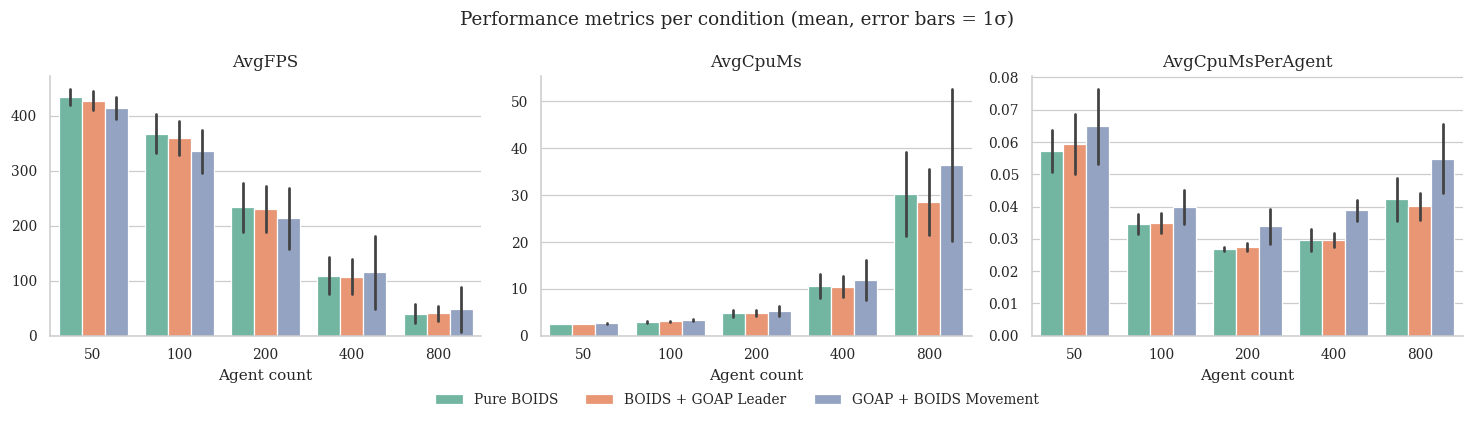

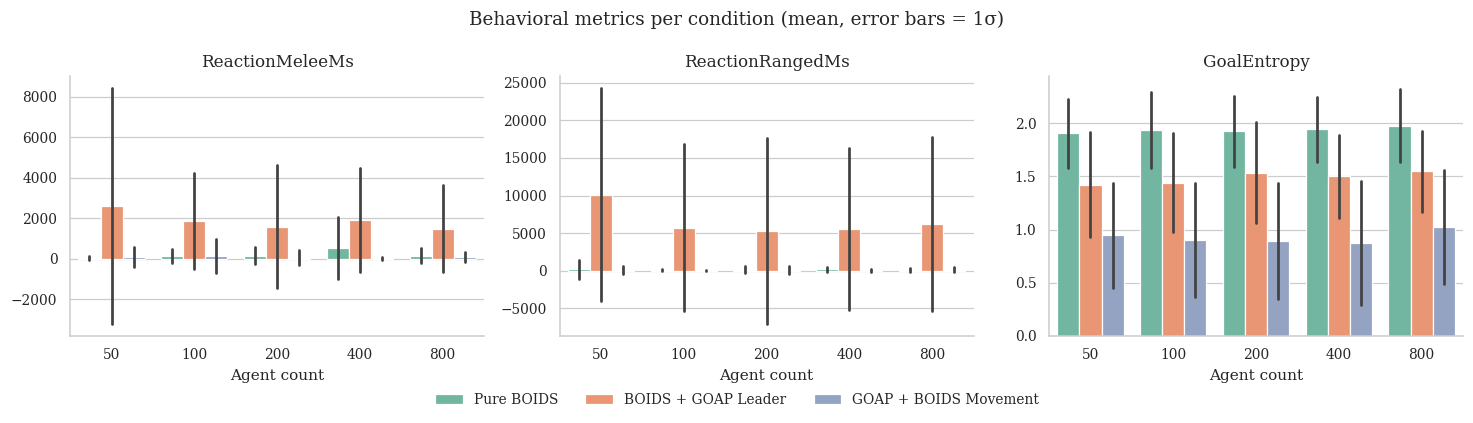

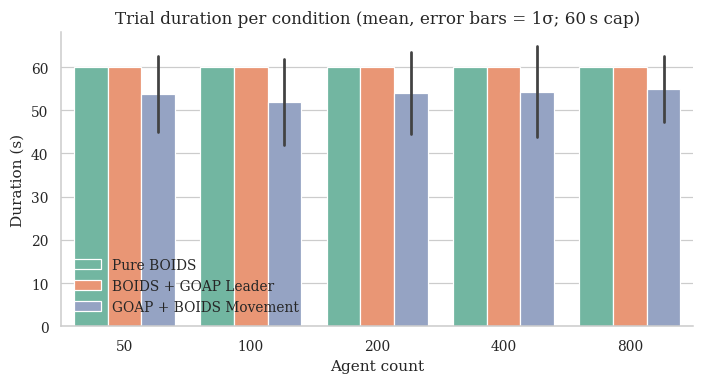

In [7]:
METRICS = ['AvgFPS', 'AvgCpuMs', 'AvgCpuMsPerAgent',
           'ReactionMeleeMs', 'ReactionRangedMs', 'GoalEntropy', 'DurationSec']

t = trials.copy()
for col in ('ReactionMeleeMs', 'ReactionRangedMs'):
    t.loc[t[col] < 0, col] = np.nan  # -1 sentinel = never reacted

sizes = sorted(t['AgentCount'].unique())

# Phase A.4 - replaces the original 7x6 (42-panel) grid with three thematic
# figures, each plotting one bar per (Condition x AgentCount) cell.
# Mean +/- sigma error bars; switch to median + IQR for the robust scaling
# figure (cell `4eef5468`).

def _grouped_bars(metrics, title, fname):
    fig, axes = plt.subplots(1, len(metrics),
                              figsize=(4.5 * len(metrics), 3.6),
                              squeeze=False)
    for ax, m in zip(axes[0], metrics):
        sns.barplot(data=t, x='AgentCount', y=m,
                    hue='Condition', hue_order=CONDITION_ORDER, palette=PALETTE,
                    errorbar='sd', ax=ax)
        ax.set_title(m)
        ax.set_xlabel('Agent count')
        ax.set_ylabel('')
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    handles, labels = axes[0, -1].get_legend_handles_labels()
    pretty_labels = [LABEL_MAP.get(l, l) for l in labels]
    fig.legend(handles, pretty_labels, loc='lower center',
               ncol=len(pretty_labels), bbox_to_anchor=(0.5, -0.05),
               frameon=False)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

# 1a - performance (FPS, CPU/frame, CPU/agent).
_grouped_bars(
    metrics=['AvgFPS', 'AvgCpuMs', 'AvgCpuMsPerAgent'],
    title='Performance metrics per condition (mean, error bars = 1σ)',
    fname=f'1a_performance_{TS}.png',
)

# 1b - behavior (reaction times + entropy).
_grouped_bars(
    metrics=['ReactionMeleeMs', 'ReactionRangedMs', 'GoalEntropy'],
    title='Behavioral metrics per condition (mean, error bars = 1σ)',
    fname=f'1b_behavior_{TS}.png',
)

# 1c - trial duration (single panel, narrower).
fig, ax = plt.subplots(figsize=(6.5, 3.6))
sns.barplot(data=t, x='AgentCount', y='DurationSec',
            hue='Condition', hue_order=CONDITION_ORDER, palette=PALETTE,
            errorbar='sd', ax=ax)
ax.set_title('Trial duration per condition (mean, error bars = 1σ; 60 s cap)')
ax.set_xlabel('Agent count'); ax.set_ylabel('Duration (s)')
leg = ax.get_legend()
if leg is not None:
    for txt in leg.get_texts():
        if txt.get_text() in LABEL_MAP:
            txt.set_text(LABEL_MAP[txt.get_text()])
    leg.set_title(None)
fig.tight_layout()
fig.savefig(FIG_DIR / f'1c_duration_{TS}.png', dpi=300, bbox_inches='tight')
plt.show()


## 2 — Goal-entropy box plot

Shannon entropy over the 9-bucket goal distribution per trial, plotted as a box per (Condition, AgentCount). Higher entropy means the flock spread its time across more goal types; lower entropy means it spent the trial in a few dominant states.

This is the canonical RQ2 *behavioral diversity* figure. A condition that mostly Wanders + Attacks scores low; one that cycles through Flee/Scatter/Regroup/Flank/Guard scores high. Compared across conditions at the same N, it answers: *did this architecture produce richer behavior at this scale?*

Entropy is computed in `BehavioralMetricsCollector.ShannonEntropy(long[])` (pure static for unit-testability; covered by `ShannonEntropyTests`). Box plot uses median + IQR, robust to the bimodal goal distributions documented in Item 5.


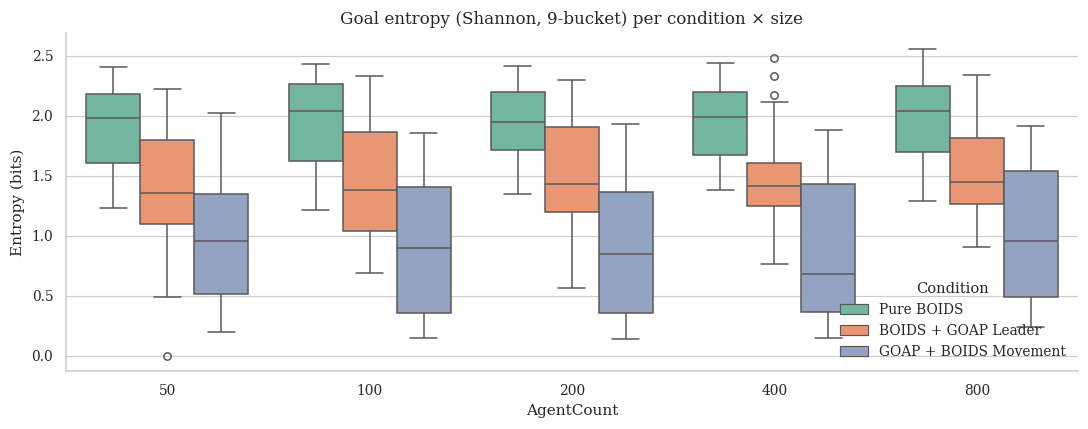

In [8]:
fig, ax = plt.subplots(figsize=(max(6, 2 * len(sizes)), 4))
sns.boxplot(data=trials, x='AgentCount', y='GoalEntropy',
            hue='Condition', palette=PALETTE, ax=ax)
ax.set_title('Goal entropy (Shannon, 9-bucket) per condition × size')
ax.set_ylabel('Entropy (bits)')
prettify(ax)
fig.tight_layout()
fig.savefig(FIG_DIR / f'2_entropy_boxplot_{TS}.png', dpi=300, bbox_inches='tight')
plt.show()

## 3 — Reaction-time histogram (melee + ranged)

Time from stimulus fire (`ExperimentRunner.ForceStimulusOnAllFlocks` at t = `stimulusWarmupSec`) to first active response per flock, in milliseconds. Shown as a histogram per (Condition, flock-type), one panel per flock type.

This is the *time-to-react* RQ2 metric. A condition that engages quickly has a tight left-leaning distribution; a slow one has a long right tail or never reacts at all (sentinel `-1`, dropped here — see Section 3b for censoring-aware analysis).

The 5 s warmup gate (Item 5 of `methodology-revisions-2026-04.md`) prevents spawn-startup events from leaking into the reaction window. Histograms shown raw; the canonical thesis number is the K-M median from Section 3b, which handles censoring honestly.


Reaction outliers > 1000ms (excluded from histogram):
Condition  PureBOIDS  BOIDSWithGOAPLeader  GOAPWithBOIDSMovement
FlockType                                                       
Melee             11                  104                      4
Ranged             8                  105                      5


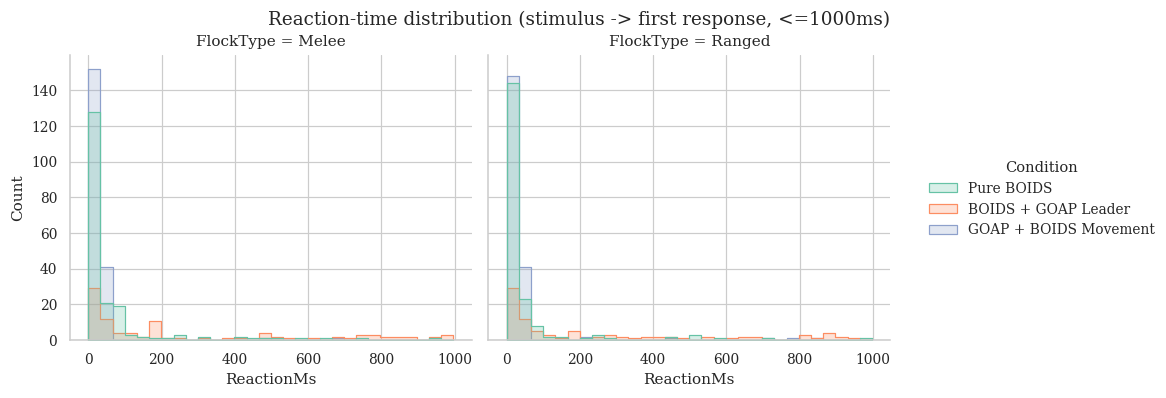


Reaction time median + IQR (ms) - robust statistics:
  ReactionMeleeMs:
                       median    q25     q75
Condition                                   
PureBOIDS                15.1    3.8    74.2
BOIDSWithGOAPLeader    1070.3  148.4  2003.9
GOAPWithBOIDSMovement     9.8    5.9    27.3
  ReactionRangedMs:
                       median    q25     q75
Condition                                   
PureBOIDS                10.2    2.4    39.1
BOIDSWithGOAPLeader    1185.5  132.8  5775.4
GOAPWithBOIDSMovement     9.8    5.9    39.1

Censored (never reacted) rates per condition:
                       MeleeCensored  RangedCensored
Condition                                           
PureBOIDS                      0.000           0.000
BOIDSWithGOAPLeader            0.005           0.035
GOAPWithBOIDSMovement          0.000           0.000


In [9]:
long = t.melt(id_vars=['Condition', 'AgentCount'],
              value_vars=['ReactionMeleeMs', 'ReactionRangedMs'],
              var_name='FlockType', value_name='ReactionMs').dropna(subset=['ReactionMs'])
long['FlockType'] = long['FlockType'].str.replace('Reaction', '').str.replace('Ms', '')

# Cap the histogram at 1000 ms so the dominant sub-second bin is readable. The
# untrimmed distribution has a long sparse tail to ~12s driven by spawn-startup
# outliers at small flock sizes (PureBOIDS-25 sigma=3893ms on mu=2766ms - bimodal).
# Tail counts logged separately so they are not silently dropped from the figure.
HIST_X_CAP = 1000
tail = long[long['ReactionMs'] > HIST_X_CAP].groupby(
    ['FlockType', 'Condition'], observed=True).size().unstack(fill_value=0)
print(f'Reaction outliers > {HIST_X_CAP}ms (excluded from histogram):')
print(tail)

g = sns.displot(long[long['ReactionMs'] <= HIST_X_CAP],
                x='ReactionMs', hue='Condition', col='FlockType',
                palette=PALETTE, kind='hist', bins=30, element='step',
                common_norm=False, stat='count', height=3.5, aspect=1.2)
g.fig.suptitle(f'Reaction-time distribution (stimulus -> first response, <={HIST_X_CAP}ms)', y=1.02)
prettify(g)
g.savefig(FIG_DIR / f'3_reaction_hist_{TS}.png', dpi=300, bbox_inches='tight')
plt.show()

# Median + IQR by condition - robust to the bimodal tail. Use this in the thesis
# text instead of mean +/- sigma for ReactionMeleeMs / ReactionRangedMs.
print('\nReaction time median + IQR (ms) - robust statistics:')
for col in ('ReactionMeleeMs', 'ReactionRangedMs'):
    pos = t[t[col] > 0]
    print(f'  {col}:')
    print(pos.groupby('Condition', observed=True)[col].agg(
        ['median', lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)]
    ).rename(columns={'median': 'median', '<lambda_0>': 'q25', '<lambda_1>': 'q75'}).round(1))

censored = trials[['Condition', 'AgentCount', 'ReactionMeleeMs', 'ReactionRangedMs']].copy()
censored['MeleeCensored']  = censored['ReactionMeleeMs']  < 0
censored['RangedCensored'] = censored['ReactionRangedMs'] < 0
print('\nCensored (never reacted) rates per condition:')
print(censored.groupby('Condition', observed=True)[['MeleeCensored', 'RangedCensored']].mean().round(3))


## 3b - Censoring-aware reaction-time analysis (methodology-revisions item 6)

Section 3 above drops `ReactionMeleeMs == -1` ("never reacted") cases before computing means and histograms. That is selection bias: trials where the flock never responded are often the most informative cases for behavioural-quality claims, but they vanish from the summary. This section handles the censoring honestly via two artifacts:

- **Censoring rate panel.** Stacked bar of "% trials per condition x flock-type where the flock never reacted to the stimulus." Use this alongside any reaction-time claim in the thesis prose.
- **Kaplan-Meier survival curves.** Right-censoring at trial end (so a censored trial contributes data up to its `DurationSec`, not nothing). Median survival time is the K-M analogue of "median reaction time" with proper handling of unreacted trials.

See [[methodology-revisions-2026-04]] item 6 for full methodology context. Requires `lifelines` (added to `analysis/requirements.txt`).

Censoring rate per (Condition, FlockType, AgentCount):
                                            pct_censored   n
Condition             FlockType AgentCount                  
BOIDSWithGOAPLeader   Melee     50                 0.025  40
                                100                0.000  40
                                200                0.000  40
                                400                0.000  40
                                800                0.000  40
                      Ranged    50                 0.050  40
                                100                0.025  40
                                200                0.050  40
                                400                0.000  40
                                800                0.050  40
GOAPWithBOIDSMovement Melee     50                 0.000  40
                                100                0.000  40
                                200                0.000  40
                              

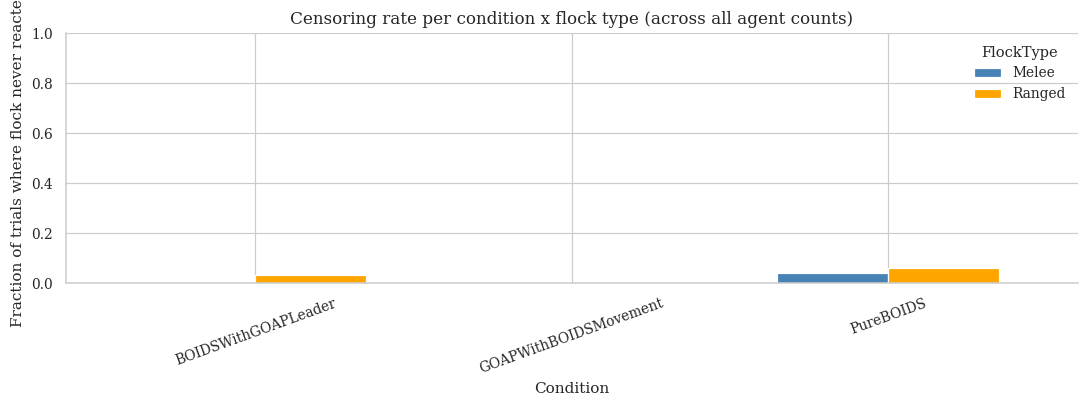

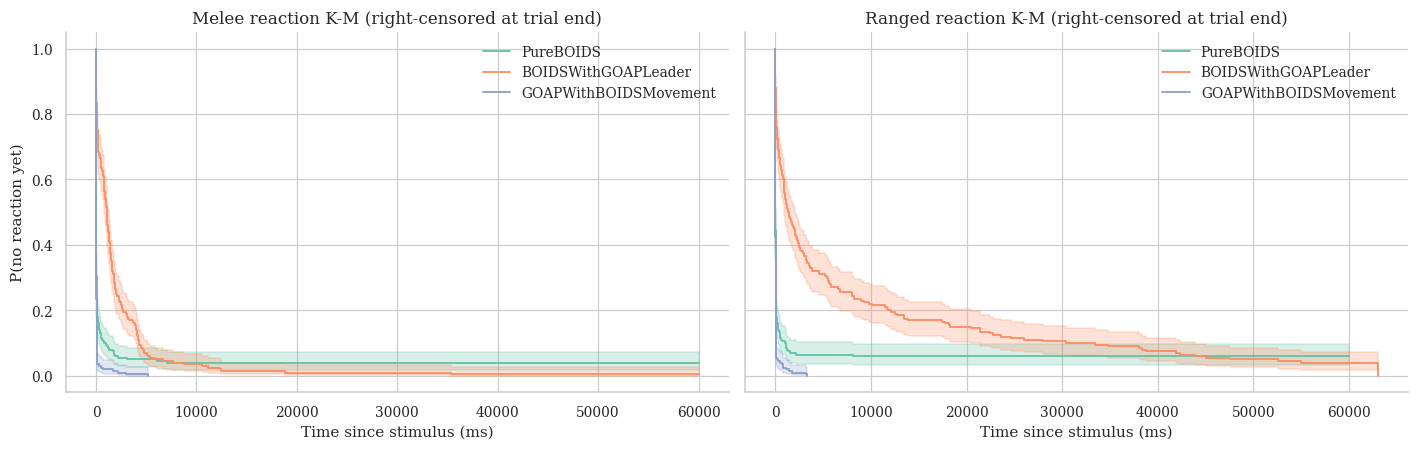


Kaplan-Meier median survival time (ms). Inf = >50% of trials censored.
                                 MedianMs    N
FlockType Condition                           
Melee     PureBOIDS                  19.5  200
          BOIDSWithGOAPLeader      1088.9  200
          GOAPWithBOIDSMovement       9.8  200
Ranged    PureBOIDS                  11.7  200
          BOIDSWithGOAPLeader      1421.9  200
          GOAPWithBOIDSMovement       9.8  200


In [10]:
# 3b: Censoring-aware reaction-time analysis (methodology-revisions item 6).
#
# Section 3 above filters out -1 sentinels ("never reacted") before computing means
# and histograms. That is selection bias: trials where the flock never responded to
# the stimulus are arguably the most informative cases for behavioural-quality claims
# but they vanish from the summary. This cell handles the censoring honestly:
#   1. Reports % of trials per (condition, flock-type) that ended without a response.
#   2. Fits Kaplan-Meier survival curves with right-censoring at trial end.
from lifelines import KaplanMeierFitter

# Build long-form: one row per (trial, flock-type). time_ms = reaction if reacted;
# trial duration in ms if censored (right-censoring at trial end).
records = []
for col, flock_type in [('ReactionMeleeMs', 'Melee'), ('ReactionRangedMs', 'Ranged')]:
    for _, row in trials.iterrows():
        rt = row[col]
        dur_ms = row['DurationSec'] * 1000.0
        if rt > 0:
            records.append(dict(time_ms=rt, event=1, FlockType=flock_type,
                                Condition=str(row['Condition']),
                                AgentCount=row['AgentCount']))
        else:
            records.append(dict(time_ms=dur_ms, event=0, FlockType=flock_type,
                                Condition=str(row['Condition']),
                                AgentCount=row['AgentCount']))
km_df = pd.DataFrame(records)

# Censoring rate per (Condition, FlockType, AgentCount).
censor_rates = (km_df.groupby(['Condition', 'FlockType', 'AgentCount'], observed=True)
                .agg(pct_censored=('event', lambda s: 1 - s.mean()),
                     n=('event', 'size'))
                .round(3))
print('Censoring rate per (Condition, FlockType, AgentCount):')
print(censor_rates)

# Censoring-rate bar chart (collapsed across AgentCount for a high-level view).
fig, ax = plt.subplots(figsize=(10, 3.8))
pivot = (km_df.groupby(['Condition', 'FlockType'], observed=True)
         .agg(pct_censored=('event', lambda s: 1 - s.mean())).reset_index()
         .pivot(index='Condition', columns='FlockType', values='pct_censored'))
pivot.plot.bar(ax=ax, color=['steelblue', 'orange'], width=0.7)
ax.set_ylabel('Fraction of trials where flock never reacted')
ax.set_title('Censoring rate per condition x flock type (across all agent counts)')
ax.set_ylim(0, 1)
ax.legend(title='FlockType', loc='best')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / f'3b_censoring_rate_{TS}.png', dpi=150, bbox_inches='tight')
plt.show()

# Kaplan-Meier survival curves (one panel per flock type).
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
km_medians = []
for ax, ftype in zip(axes, ['Melee', 'Ranged']):
    sub = km_df[km_df['FlockType'] == ftype]
    for cond in CONDITION_ORDER:
        cs = sub[sub['Condition'] == cond]
        if len(cs) == 0:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(cs['time_ms'], cs['event'], label=cond)
        kmf.plot_survival_function(ax=ax, color=PALETTE[cond], ci_show=True)
        km_medians.append(dict(FlockType=ftype, Condition=cond,
                               MedianMs=kmf.median_survival_time_, N=len(cs)))
    ax.set_title(f'{ftype} reaction K-M (right-censored at trial end)')
    ax.set_xlabel('Time since stimulus (ms)')
    ax.set_ylabel('P(no reaction yet)')
fig.tight_layout()
fig.savefig(FIG_DIR / f'3b_km_reaction_{TS}.png', dpi=150, bbox_inches='tight')
plt.show()

# Median survival times - the K-M analogue of "median reaction time" with
# right-censoring honestly handled. Use these in thesis prose; flag the
# censoring rate from the table above alongside any claim.
print('\nKaplan-Meier median survival time (ms). Inf = >50% of trials censored.')
print(pd.DataFrame(km_medians).set_index(['FlockType', 'Condition']).round(1))


## 4 — Scaling curves

For each metric, one line per condition with mean across runs, x-axis = AgentCount. This is the *raw* scaling view — mean-of-mean across configured N.

**Use Figure 4b instead for thesis claims.** Section 4 is shown for sanity-check / continuity with the original v1 narrative; 4b applies the 5 s warmup trim and reports median + IQR, which survives the bimodal frame-stall variance at high N. The Section 4 bars exist primarily so reviewers comparing this notebook to the 2026-04-26 batch report see continuity with the older numbers.


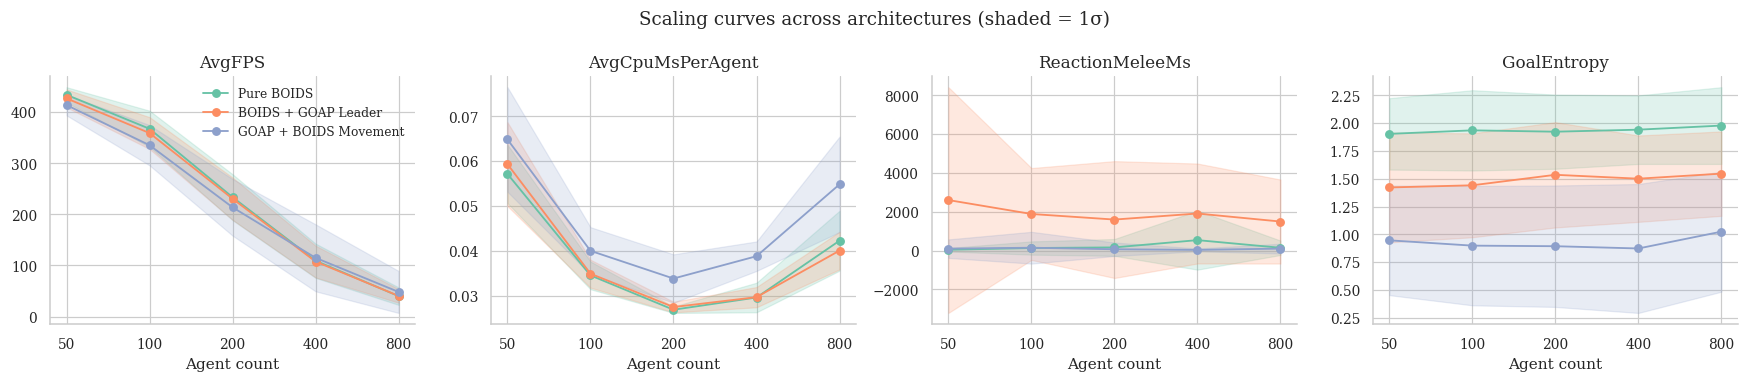

In [11]:
SCALING_METRICS = ['AvgFPS', 'AvgCpuMsPerAgent', 'ReactionMeleeMs', 'GoalEntropy']
agg = t.groupby(['Condition', 'AgentCount'], observed=True)[SCALING_METRICS]\
       .agg(['mean', 'std']).reset_index()

fig, axes = plt.subplots(1, len(SCALING_METRICS), figsize=(4 * len(SCALING_METRICS), 3.5))
for ax, m in zip(axes, SCALING_METRICS):
    for cond in CONDITION_ORDER:
        sub = agg[agg['Condition'] == cond].sort_values('AgentCount')
        if sub.empty: continue
        x = sub['AgentCount']
        y = sub[(m, 'mean')]
        s = sub[(m, 'std')].fillna(0)
        ax.plot(x, y, marker='o', color=PALETTE[cond], label=cond)
        ax.fill_between(x, y - s, y + s, alpha=0.2, color=PALETTE[cond])
    ax.set_title(m); ax.set_xlabel('Agent count'); ax.set_xscale('log', base=2)
    ax.set_xticks(sorted(t['AgentCount'].unique()))
    ax.set_xticklabels(sorted(t['AgentCount'].unique()))
axes[0].legend(loc='best', fontsize=8)
fig.suptitle('Scaling curves across architectures (shaded = 1σ)')
prettify(fig)
fig.tight_layout()
fig.savefig(FIG_DIR / f'4_scaling_curves_{TS}.png', dpi=300, bbox_inches='tight')
plt.show()

### 4b - Warmup-trimmed scaling curves (median + IQR)

The 5 s warmup trim removes spawn-startup distortion; median + IQR is robust to
the bimodal frame-stall variance at high N. This is the **defensible RQ1 figure**
for the thesis Results chapter - same axes as Figure 4 above, but every point
represents fair steady-state behavior.

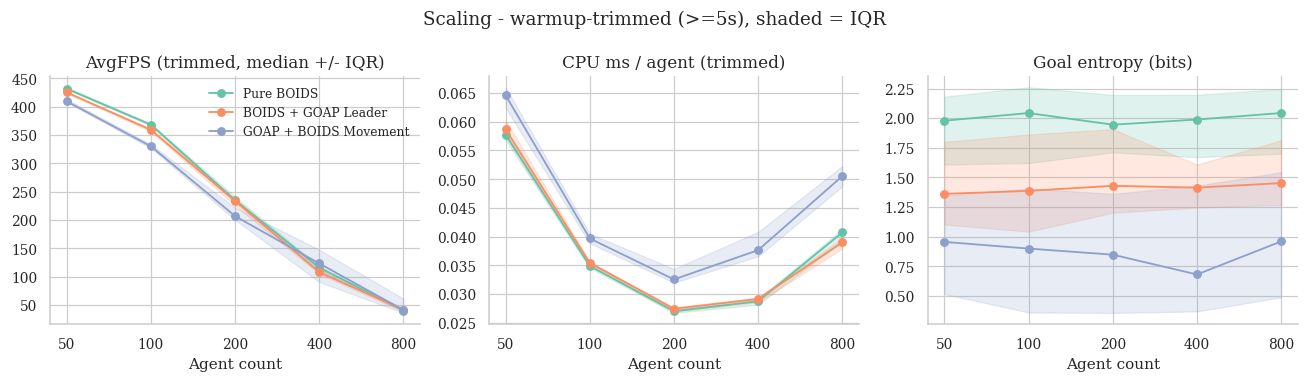

In [12]:
def q25(s): return s.quantile(0.25)
def q75(s): return s.quantile(0.75)

SCALING_METRICS_ROBUST = [
    ('AvgFPS_trimmed', 'AvgFPS (trimmed, median +/- IQR)'),
    ('AvgCpuMsPerAgent_trimmed', 'CPU ms / agent (trimmed)'),
    ('GoalEntropy', 'Goal entropy (bits)'),
]

agg_r = trials.groupby(['Condition', 'AgentCount'], observed=True).agg(
    **{f'{m}_med': (m, 'median') for m, _ in SCALING_METRICS_ROBUST},
    **{f'{m}_q25': (m, q25)      for m, _ in SCALING_METRICS_ROBUST},
    **{f'{m}_q75': (m, q75)      for m, _ in SCALING_METRICS_ROBUST},
).reset_index()

fig, axes = plt.subplots(1, len(SCALING_METRICS_ROBUST),
                          figsize=(4 * len(SCALING_METRICS_ROBUST), 3.5))
for ax, (m, title) in zip(axes, SCALING_METRICS_ROBUST):
    for cond in CONDITION_ORDER:
        sub = agg_r[agg_r['Condition'] == cond].sort_values('AgentCount')
        if sub.empty: continue
        x = sub['AgentCount']
        med = sub[f'{m}_med']
        lo = sub[f'{m}_q25']
        hi = sub[f'{m}_q75']
        ax.plot(x, med, marker='o', color=PALETTE[cond], label=cond)
        ax.fill_between(x, lo, hi, alpha=0.2, color=PALETTE[cond])
    ax.set_title(title); ax.set_xlabel('Agent count'); ax.set_xscale('log', base=2)
    sweep = sorted(trials['AgentCount'].unique())
    ax.set_xticks(sweep); ax.set_xticklabels(sweep)
axes[0].legend(loc='best', fontsize=8)
fig.suptitle(f'Scaling - warmup-trimmed (>={WARMUP_SEC:.0f}s), shaded = IQR')
prettify(fig)
fig.tight_layout()
fig.savefig(FIG_DIR / f'4b_scaling_trimmed_{TS}.png', dpi=300, bbox_inches='tight')
plt.show()


## 5 — Trial outcomes

Stacked bar per (Condition, AgentCount) showing the proportion of trials that ended in each `Outcome` value: `PlayerDeath`, `FlockWiped`, `TimeLimit`. Sourced from the TrialSummary CSV.

This is RQ2 evidence in its most direct form: *given a fixed scenario, how often did this architecture defeat the player vs get wiped vs run out the clock?* PureBOIDS that scatters effectively will show high `TimeLimit` (no decisive outcome). A tightly-cohered Leader flock that gets AOE'd will show high `FlockWiped`. A condition that punches through to player melee will show `PlayerDeath`.

Combined with `DamagePerSecondToPlayer` and `AgentsKilledByPlayer` (added 2026-04-26), this is the combat-effectiveness panel for the thesis Results chapter.


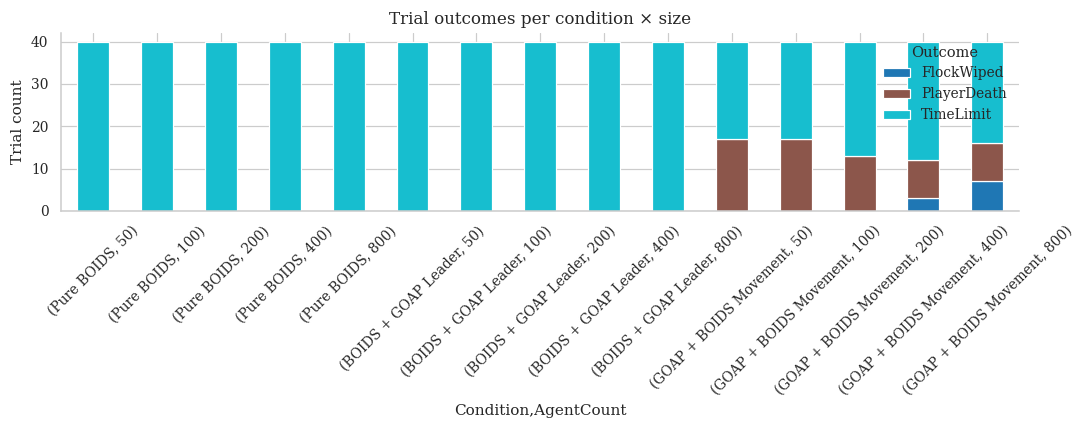

Outcome                           FlockWiped  PlayerDeath  TimeLimit
Condition             AgentCount                                    
PureBOIDS             50                   0            0         40
                      100                  0            0         40
                      200                  0            0         40
                      400                  0            0         40
                      800                  0            0         40
BOIDSWithGOAPLeader   50                   0            0         40
                      100                  0            0         40
                      200                  0            0         40
                      400                  0            0         40
                      800                  0            0         40
GOAPWithBOIDSMovement 50                   0           17         23
                      100                  0           17         23
                      200                  0           13         27
                      400                  3            9         28
                      800                  7            9         24

In [13]:
outcomes = (trials.groupby(['Condition', 'AgentCount', 'Outcome'], observed=True)
                  .size().unstack(fill_value=0))
# Pretty up the (Condition, AgentCount) MultiIndex for the x-tick labels.
outcomes_pretty = outcomes.copy()
outcomes_pretty.index = pd.MultiIndex.from_tuples(
    [(LABEL_MAP.get(c, c), n) for c, n in outcomes_pretty.index],
    names=outcomes_pretty.index.names,
)
fig, ax = plt.subplots(figsize=(max(7, 2 * len(sizes)), 4))
outcomes_pretty.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_ylabel('Trial count')
ax.set_title('Trial outcomes per condition × size')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig(FIG_DIR / f'5_outcomes_{TS}.png', dpi=300, bbox_inches='tight')
plt.show()
outcomes

## 6 — FPS-over-time sanity check (one representative run per condition × size)

Per-frame FPS plotted against trial-elapsed time, for one representative run from each (Condition, AgentCount) cell. Sourced from the Performance CSV.

This is the *visual diagnostic* for: did this trial actually run at steady-state, or did it have a frame stall, a GC spike, or a gradual degradation? At high N you'll see PureBOIDS settle into a flat steady-state, GOAPWithBOIDSMovement gradually decline as the GOAP planners grind on more agents, and BOIDSWithGOAPLeader stay relatively flat (its per-agent cost is low because most agents are reactive followers).

Useful for a thesis figure when you want to *show* (not just summarize) how a condition behaves over the trial. The single-run-per-cell choice keeps the plot legible; for full distribution see Section 4b.


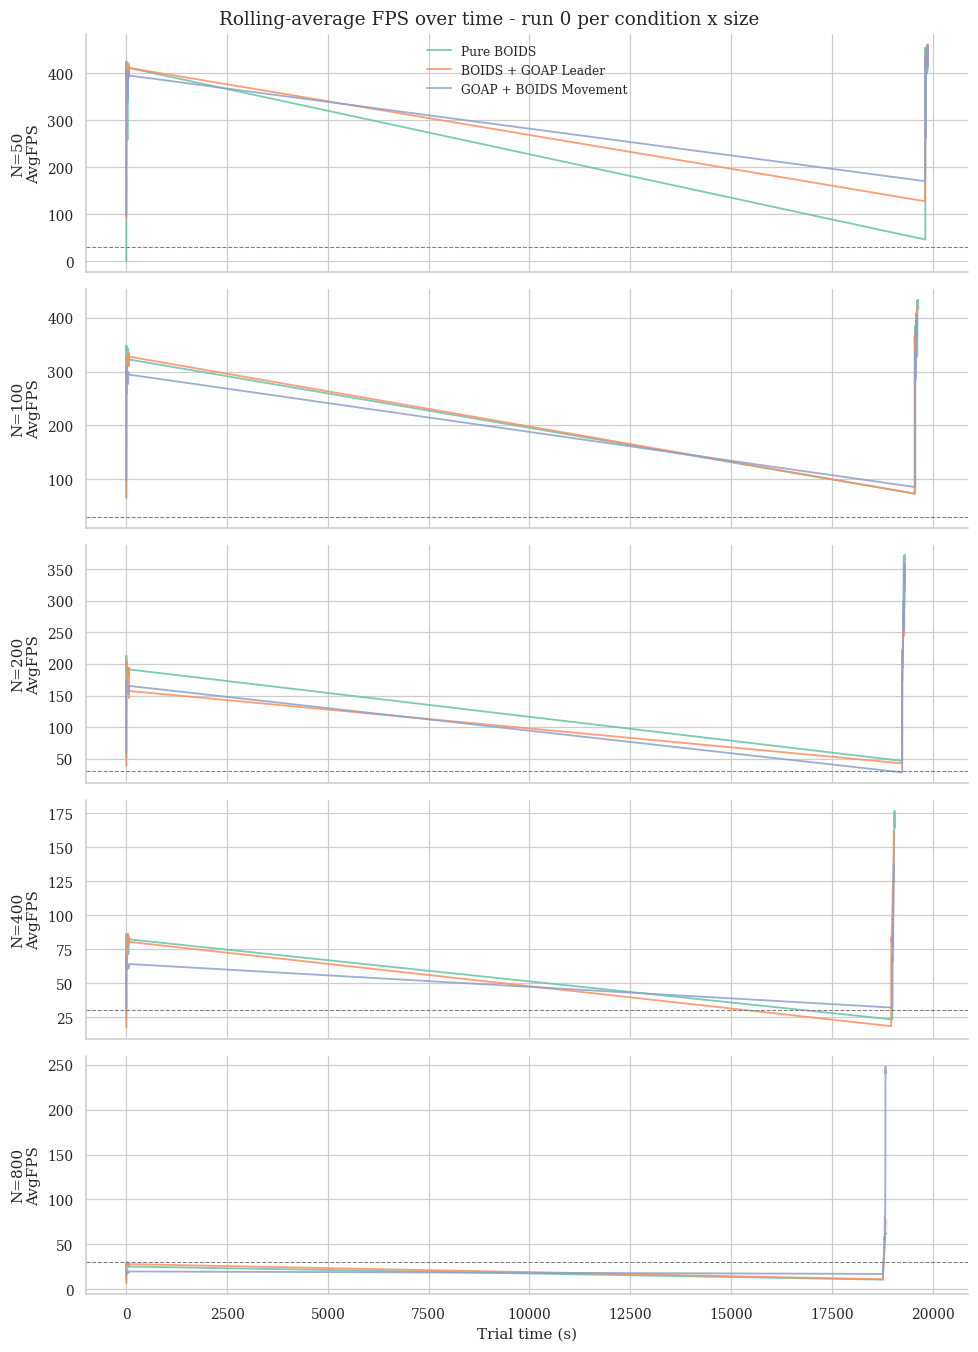

In [14]:
# Look up the per-trial Seed from TrialSummary then filter perf by (Condition, Seed)
# - the *only* unique trial key shared by both files. perf['AgentCount'] is the LIVE
# per-frame count, NOT the configured trial size, so don't filter on it.
fig, axes = plt.subplots(len(sizes), 1, figsize=(9, 2.5 * len(sizes)), sharex=True, squeeze=False)
for i, sz in enumerate(sizes):
    ax = axes[i, 0]
    for cond in CONDITION_ORDER:
        match = trials[(trials['Condition'] == cond)
                       & (trials['AgentCount'] == sz)
                       & (trials['RunId'] == 0)]
        if match.empty: continue
        seed = int(match['Seed'].iloc[0])
        sub = perf[(perf['Condition'] == cond) & (perf['Seed'] == seed)].copy()
        if sub.empty: continue
        # `Time` is a global wall-clock counter incrementing across all trials in
        # the batch - subtract the per-trial start so each trace renders on a
        # 0..DurationSec axis instead of a global 0..~8000s axis.
        sub['TrialTime'] = sub['Time'] - sub['Time'].min()
        ax.plot(sub['TrialTime'], sub['AvgFPS'], color=PALETTE[cond], label=cond, alpha=0.85)
    ax.set_ylabel(f'N={sz}\nAvgFPS')
    ax.axhline(30, color='grey', linestyle='--', linewidth=0.7)
axes[0, 0].legend(loc='best', fontsize=8)
axes[-1, 0].set_xlabel('Trial time (s)')
fig.suptitle('Rolling-average FPS over time - run 0 per condition x size')
prettify(fig)
fig.tight_layout()
fig.savefig(FIG_DIR / f'6_fps_traces_{TS}.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Summary table (thesis-ready)

In [15]:
summary = (t.groupby(['Condition', 'AgentCount'], observed=True)[METRICS]
            .agg(['mean', 'std']).round(2))
summary.to_csv(FIG_DIR / f'summary_{TS}.csv')
summary

AvgFPS        AvgCpuMs         \
                                    mean    std     mean    std   
Condition             AgentCount                                  
PureBOIDS             50          433.78  14.88     2.49   0.06   
                      100         367.35  35.39     3.00   0.18   
                      200         233.59  44.87     4.76   0.67   
                      400         109.32  33.46    10.58   2.60   
                      800          40.09  17.09    30.21   8.98   
BOIDSWithGOAPLeader   50          426.80  17.46     2.54   0.07   
                      100         358.99  31.15     3.07   0.15   
                      200         230.58  41.35     4.79   0.62   
                      400         107.70  31.02    10.50   2.27   
                      800          40.56  13.32    28.47   7.05   
GOAPWithBOIDSMovement 50          413.72  20.11     2.63   0.07   
                      100         335.23  39.37     3.31   0.24   
                      200         213.75  55.37     5.32   1.00   
                      400         115.00  65.48    11.94   4.32   
                      800          48.29  41.04    36.43  16.25   

                                 AvgCpuMsPerAgent       ReactionMeleeMs  \
                                             mean   std            mean   
Condition             AgentCount                                          
PureBOIDS             50                     0.06  0.01           40.31   
                      100                    0.03  0.00          128.57   
                      200                    0.03  0.00          160.40   
                      400                    0.03  0.00          535.93   
                      800                    0.04  0.01          141.43   
BOIDSWithGOAPLeader   50                     0.06  0.01         2602.16   
                      100                    0.03  0.00         1884.16   
                      200                    0.03  0.00         1596.44   
                      400                    0.03  0.00         1908.11   
                      800                    0.04  0.00         1494.47   
GOAPWithBOIDSMovement 50                     0.06  0.01           96.15   
                      100                    0.04  0.01          144.45   
                      200                    0.03  0.01           64.90   
                      400                    0.04  0.00           32.68   
                      800                    0.05  0.01           98.41   

                                          ReactionRangedMs            \
                                      std             mean       std   
Condition             AgentCount                                       
PureBOIDS             50            90.94           207.70   1279.36   
                      100          341.67            42.15    136.93   
                      200          433.29           160.78    419.10   
                      400         1522.26           163.57    381.63   
                      800          371.42            97.66    208.81   
BOIDSWithGOAPLeader   50          5820.30         10111.17  14164.98   
                      100         2368.73          5749.77  11132.82   
                      200         3013.10          5314.01  12402.71   
                      400         2577.61          5579.93  10756.83   
                      800         2166.08          6212.87  11519.58   
GOAPWithBOIDSMovement 50           477.40           112.29    527.62   
                      100          819.54            31.56    125.14   
                      200          346.75           103.74    530.62   
                      400           72.71            65.32    198.34   
                      800          251.38           135.18    341.50   

                                 GoalEntropy       DurationSec         
                                        mean   std        mean    std  
Condition             AgentCount   

## Robust statistics (median + IQR + warmup-trimmed)

Mean +/- sigma is misleading for the high-N FPS columns (CV >50% from bimodal frame stalls)
and the small-N reaction-time columns (CV >100% from spawn-startup outliers). The table
below reports **median, q25, q75** alongside the warmup-trimmed AvgFPS, which gives a
fairer steady-state RQ1 comparison. Use this for the thesis Results section.

In [16]:
ROBUST_METRICS = ['AvgFPS', 'AvgFPS_trimmed', 'AvgCpuMs', 'AvgCpuMs_trimmed',
                  'AvgCpuMsPerAgent', 'AvgCpuMsPerAgent_trimmed',
                  'GoalEntropy', 'DurationSec']
robust = (trials.groupby(['Condition', 'AgentCount'], observed=True)[ROBUST_METRICS]
                .agg(['median', q25, q75]).round(2))
robust.to_csv(FIG_DIR / f'robust_summary_{TS}.csv')
robust


AvgFPS                 AvgFPS_trimmed  \
                                  median     q25     q75         median   
Condition             AgentCount                                          
PureBOIDS             50          434.70  421.42  448.28         431.91   
                      100         367.05  334.58  401.62         368.39   
                      200         222.85  190.55  273.95         234.85   
                      400          96.20   77.05  142.12         115.80   
                      800          37.30   26.18   50.25          39.92   
BOIDSWithGOAPLeader   50          427.75  409.83  443.72         425.46   
                      100         355.90  328.70  389.05         359.11   
                      200         220.00  191.60  268.95         233.37   
                      400          93.75   79.57  133.18         107.61   
                      800          36.00   28.60   51.02          41.10   
GOAPWithBOIDSMovement 50          412.30  394.58  432.65         409.58   
                      100         327.15  297.10  373.75         330.10   
                      200         199.80  162.78  252.10         206.75   
                      400          84.40   62.70  156.57         123.05   
                      800          26.75   19.48   58.42          40.65   

                                                 AvgCpuMs                \
                                     q25     q75   median    q25    q75   
Condition             AgentCount                                          
PureBOIDS             50          430.48  434.61     2.49   2.44   2.53   
                      100         366.37  370.25     2.99   2.82   3.16   
                      200         231.42  241.13     4.83   4.14   5.41   
                      400         110.91  117.88    11.25   7.92  13.10   
                      800          39.19   42.11    30.23  22.23  38.62   
BOIDSWithGOAPLeader   50          423.66  426.23     2.54   2.48   2.60   
                      100         356.62  361.64     3.09   2.94   3.20   
                      200         225.67  237.56     4.87   4.21   5.38   
                      400         104.65  114.48    11.10   8.57  12.65   
                      800          37.88   44.41    29.52  21.82  35.20   
GOAPWithBOIDSMovement 50          408.12  413.28     2.66   2.57   2.70   
                      100         326.91  333.64     3.38   3.07   3.53   
                      200         200.08  221.77     5.46   4.48   6.28   
                      400          90.41  147.33    12.97   7.64  16.03   
                      800          35.70   61.01    41.44  22.23  51.72   

                                 AvgCpuMs_trimmed  ... AvgCpuMsPerAgent  \
                                           median  ...              q75   
Condition             AgentCount                   ...                    
PureBOIDS             50                     2.49  ...             0.06   
                      100                    2.98  ...             0.04   
                      200                    4.69  ...             0.03   
                      400                    9.73  ...             0.03   
                      800                   27.81  ...             0.05   
BOIDSWithGOAPLeader   50                     2.54  ...             0.06   
                      100                    3.06  ...             0.04   
                      200                    4.68  ...             0.03   
                      400                   10.17  ...             0.03   
                      800                   26.60  ...             0.04   
GOAPWithBOIDSMovement 50                     2.64  ...             0.08   
                      100                    3.32  ...             0.04   
                      200                    5.30  ...             0.03   
                      400                   10.32  ...             0.04   
                      800                   31.08  ...   

---
## LaTeX-table export

Phase A.3. Writes three `.tex` files under `analysis/tables/`:
- `summary_{TS}.tex` — full mean ± σ table.
- `robust_summary_{TS}.tex` — full median + IQR + warmup-trimmed table.
- `thesis_table1_fps_{TS}.tex` — condensed FPS-only table (paste straight into the Results chapter as Table 1).

All three wrap their `tabular` in a `table` environment with a caption and `\label{...}`. The Condition column is shown using the display labels (`Pure BOIDS`, `BOIDS + GOAP Leader`, `GOAP + BOIDS Movement`) — internal column values in the underlying CSVs are unchanged.

In [17]:
# Phase A.3 - LaTeX-table export for the thesis Results chapter.
#
# Three .tex files are written to analysis/tables/:
#   1. summary_{TS}.tex              - mean +/- sigma (full)
#   2. robust_summary_{TS}.tex       - median + IQR + warmup-trimmed (full)
#   3. thesis_table1_fps_{TS}.tex    - condensed FPS-only "median [q25, q75]" -
#                                       paste this directly into the thesis Results
#                                       section as Table 1.
# All three use LABEL_MAP for the Condition row labels.

def _wrap_latex(tabular_str, caption, label):
    return (
        '\\begin{table}[htbp]\n'
        '  \\centering\n'
        f'  \\caption{{{caption}}}\n'
        f'  \\label{{{label}}}\n'
        f'{tabular_str}'
        '\\end{table}\n'
    )

def _pretty_idx(df):
    """Replace internal Condition names in a (Condition, AgentCount) MultiIndex."""
    out = df.copy()
    if isinstance(out.index, pd.MultiIndex):
        out.index = pd.MultiIndex.from_tuples(
            [(LABEL_MAP.get(c, c), n) for c, n in out.index],
            names=out.index.names,
        )
    return out

# 1. mean +/- sigma (full table).
summary_pretty = _pretty_idx(summary)
tabular = summary_pretty.to_latex(
    escape=True, multirow=True, multicolumn=True,
    multicolumn_format='c', float_format='%.2f',
)
out = _wrap_latex(
    tabular,
    caption=f'Mean $\\pm\\sigma$ per condition $\\times$ agent count (batch {TS}).',
    label='tab:summary-mean-sigma',
)
(TEX_DIR / f'summary_{TS}.tex').write_text(out, encoding='utf-8')
print(f'wrote {TEX_DIR / f"summary_{TS}.tex"}')

# 2. median + IQR + warmup-trimmed (full table).
robust_pretty = _pretty_idx(robust)
tabular = robust_pretty.to_latex(
    escape=True, multirow=True, multicolumn=True,
    multicolumn_format='c', float_format='%.2f',
)
out = _wrap_latex(
    tabular,
    caption=(f'Median + IQR per condition $\\times$ agent count, including '
             f'warmup-trimmed ($>{WARMUP_SEC:.0f}\\,$s) variants (batch {TS}).'),
    label='tab:summary-median-iqr',
)
(TEX_DIR / f'robust_summary_{TS}.tex').write_text(out, encoding='utf-8')
print(f'wrote {TEX_DIR / f"robust_summary_{TS}.tex"}')

# 3. Thesis Table 1 - condensed FPS view as "median [q25, q75]" strings.
def _fmt_iqr(med, lo, hi):
    return f'{med:.0f} [{lo:.0f}, {hi:.0f}]'

table1_rows = []
for cond in CONDITION_ORDER:
    for n in sorted(trials['AgentCount'].unique()):
        cell = robust.loc[(cond, n)]
        raw = _fmt_iqr(cell[('AvgFPS', 'median')],
                       cell[('AvgFPS', 'q25')],
                       cell[('AvgFPS', 'q75')])
        trm = _fmt_iqr(cell[('AvgFPS_trimmed', 'median')],
                       cell[('AvgFPS_trimmed', 'q25')],
                       cell[('AvgFPS_trimmed', 'q75')])
        table1_rows.append({
            'Condition':         LABEL_MAP[cond],
            'N':                 n,
            'FPS (raw)':         raw,
            'FPS (trimmed)':     trm,
        })
table1 = pd.DataFrame(table1_rows).set_index(['Condition', 'N'])
tabular = table1.to_latex(escape=True, multirow=True, column_format='llrr')
out = _wrap_latex(
    tabular,
    caption=('Per-trial median FPS [q25, q75] by architecture and configured agent '
             'count. Trimmed variant excludes the first 5\\,s of each trial '
             f'(steady-state). Source: batch {TS}, 10 runs per cell.'),
    label='tab:fps-by-architecture',
)
(TEX_DIR / f'thesis_table1_fps_{TS}.tex').write_text(out, encoding='utf-8')
print(f'wrote {TEX_DIR / f"thesis_table1_fps_{TS}.tex"}')

table1


wrote tables\summary_2026-05-05_02-43-09.tex
wrote tables\robust_summary_2026-05-05_02-43-09.tex
wrote tables\thesis_table1_fps_2026-05-05_02-43-09.tex


FPS (raw)   FPS (trimmed)
Condition             N                                  
Pure BOIDS            50   435 [421, 448]  432 [430, 435]
                      100  367 [335, 402]  368 [366, 370]
                      200  223 [191, 274]  235 [231, 241]
                      400    96 [77, 142]  116 [111, 118]
                      800     37 [26, 50]     40 [39, 42]
BOIDS + GOAP Leader   50   428 [410, 444]  425 [424, 426]
                      100  356 [329, 389]  359 [357, 362]
                      200  220 [192, 269]  233 [226, 238]
                      400    94 [80, 133]  108 [105, 114]
                      800     36 [29, 51]     41 [38, 44]
GOAP + BOIDS Movement 50   412 [395, 433]  410 [408, 413]
                      100  327 [297, 374]  330 [327, 334]
                      200  200 [163, 252]  207 [200, 222]
                      400    84 [63, 157]   123 [90, 147]
                      800     27 [19, 58]     41 [36, 61]

---
## Inferential statistics — Two-way ANOVA + Tukey HSD

Phase C. Tests for §4.5 / §5.x:
- **Two-way ANOVA** (Condition × AgentCount, type II) on `AvgFPS_trimmed` and `AvgCpuMsPerAgent_trimmed`. Reports F, p, and η² (effect size).
- **Tukey HSD post-hoc** per AgentCount slice on `AvgFPS_trimmed`. Tells us which condition pairs differ at each agent count for the Discussion chapter.

Outputs written to `analysis/figures/`:
- `anova_AvgFPS_trimmed_{TS}.csv`
- `anova_AvgCpuMsPerAgent_trimmed_{TS}.csv`
- `tukey_AvgFPS_trimmed_{TS}.csv`

Requires `scipy>=1.10` and `statsmodels>=0.14` (added to `requirements.txt`).

In [18]:
# Phase C - Two-way ANOVA + Tukey HSD on warmup-trimmed steady-state metrics.
#
# Tests for §4.5 / §5.x: is the (Condition x AgentCount) interaction significant
# for FPS and per-agent CPU? Pairwise post-hoc tells us which conditions differ
# at each agent count.
#
# Effect size: eta-squared (η²) = SS_effect / SS_total. Conventional thresholds
# are 0.01 (small), 0.06 (medium), 0.14 (large).
#
# Output: printed ANOVA tables + Tukey results, plus a CSV per metric to
# analysis/figures/anova_{metric}_{TS}.csv for thesis tables.

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Cast Condition + AgentCount as plain strings so statsmodels treats both as
# categorical predictors in the formula. (Categorical dtype works too but is
# noisier in the printed table.)
anova_df = trials[['Condition', 'AgentCount',
                   'AvgFPS_trimmed', 'AvgCpuMsPerAgent_trimmed',
                   'AvgFPS', 'AvgCpuMsPerAgent']].copy()
anova_df['Condition'] = anova_df['Condition'].astype(str)
anova_df['AgentCount'] = anova_df['AgentCount'].astype(int)

ANOVA_METRICS = ['AvgFPS_trimmed', 'AvgCpuMsPerAgent_trimmed']

def two_way_anova(df, metric):
    """Type-II ANOVA on Condition × AgentCount + interaction. Returns table with η²."""
    model = ols(f'{metric} ~ C(Condition) * C(AgentCount)', data=df).fit()
    table = sm.stats.anova_lm(model, typ=2)
    ss_total = table['sum_sq'].sum()
    table['eta_sq'] = table['sum_sq'] / ss_total
    return table, model

print('=' * 78)
print(f'Two-way ANOVA — Condition × AgentCount (batch {TS})')
print('=' * 78)

for metric in ANOVA_METRICS:
    print(f'\n### {metric}\n')
    table, _ = two_way_anova(anova_df, metric)
    print(table.round(4))
    table.to_csv(FIG_DIR / f'anova_{metric}_{TS}.csv')

# Tukey HSD post-hoc, per AgentCount slice. Reports adjusted p-values for every
# pair (Condition_i vs Condition_j) so we can say "at N=400, BOIDS+Leader differs
# from PureBOIDS at p<X" for the thesis Discussion.

print('\n' + '=' * 78)
print('Tukey HSD post-hoc (per AgentCount, on AvgFPS_trimmed)')
print('=' * 78)

tukey_rows = []
for n in sorted(anova_df['AgentCount'].unique()):
    sub = anova_df[anova_df['AgentCount'] == n]
    if sub['Condition'].nunique() < 2 or len(sub) < 4:
        continue
    res = pairwise_tukeyhsd(endog=sub['AvgFPS_trimmed'], groups=sub['Condition'],
                            alpha=0.05)
    for row in res._results_table.data[1:]:
        # row schema: [group1, group2, meandiff, p-adj, lower, upper, reject]
        tukey_rows.append({
            'AgentCount': n,
            'group1':     LABEL_MAP.get(row[0], row[0]),
            'group2':     LABEL_MAP.get(row[1], row[1]),
            'meandiff':   row[2],
            'p_adj':      row[3],
            'lower_ci':   row[4],
            'upper_ci':   row[5],
            'reject':     row[6],
        })

tukey_df = pd.DataFrame(tukey_rows)
print(tukey_df.round(3).to_string(index=False))
tukey_df.to_csv(FIG_DIR / f'tukey_AvgFPS_trimmed_{TS}.csv', index=False)

print(f'\nWrote: anova_AvgFPS_trimmed_{TS}.csv, anova_AvgCpuMsPerAgent_trimmed_{TS}.csv, tukey_AvgFPS_trimmed_{TS}.csv')


Two-way ANOVA — Condition × AgentCount (batch 2026-05-05_02-43-09)

### AvgFPS_trimmed

                                  sum_sq     df           F  PR(>F)  eta_sq
C(Condition)                1.429806e+04    2.0     29.8501     0.0  0.0012
C(AgentCount)               1.183273e+07    4.0  12351.5897     0.0  0.9833
C(Condition):C(AgentCount)  4.675895e+04    8.0     24.4047     0.0  0.0039
Residual                    1.401064e+05  585.0         NaN     NaN  0.0116

### AvgCpuMsPerAgent_trimmed

                            sum_sq     df          F  PR(>F)  eta_sq
C(Condition)                0.0080    2.0   686.0668     0.0  0.0934
C(AgentCount)               0.0736    4.0  3146.6709     0.0  0.8566
C(Condition):C(AgentCount)  0.0009    8.0    18.7047     0.0  0.0102
Residual                    0.0034  585.0        NaN     NaN  0.0398

Tukey HSD post-hoc (per AgentCount, on AvgFPS_trimmed)


 AgentCount                group1                group2  meandiff  p_adj  lower_ci  upper_ci  reject
         50   BOIDS + GOAP Leader GOAP + BOIDS Movement   -15.063  0.000   -16.468   -13.657    True
         50   BOIDS + GOAP Leader            Pure BOIDS     6.911  0.000     5.505     8.316    True
         50 GOAP + BOIDS Movement            Pure BOIDS    21.973  0.000    20.568    23.379    True
        100   BOIDS + GOAP Leader GOAP + BOIDS Movement   -28.597  0.000   -31.025   -26.168    True
        100   BOIDS + GOAP Leader            Pure BOIDS     9.036  0.000     6.607    11.465    True
        100 GOAP + BOIDS Movement            Pure BOIDS    37.632  0.000    35.204    40.061    True
        200   BOIDS + GOAP Leader GOAP + BOIDS Movement   -17.796  0.000   -25.838    -9.754    True
        200   BOIDS + GOAP Leader            Pure BOIDS     4.794  0.336    -3.248    12.836   False
        200 GOAP + BOIDS Movement            Pure BOIDS    22.590  0.000    14.548    30.63

---
## Non-parametric inferential statistics + bootstrap CIs

**Companion to the parametric Two-way ANOVA above.** Two reasons to run a non-parametric pass alongside it:

1. **Bimodal distributions.** Reaction-time data, FPS at high N, and goal entropy are all bimodal in smaller cells (see Item 5 of `methodology-revisions-2026-04.md`). ANOVA assumes per-cell normality; the thesis should not stake its statistical claim on a single test that the data may violate.
2. **Robust effect sizes.** Bootstrap 95% CIs for the median answer *"given this data, where is the true median likely to lie?"* without requiring the data to be normal — exactly the question Figure 4b's error bars need to answer.

### What each piece does

**Kruskal–Wallis** (`scipy.stats.kruskal`) is the non-parametric one-way ANOVA. For each (metric × AgentCount) cell, it asks: *"are the three condition distributions drawn from the same underlying distribution?"* It works on ranks rather than raw values, so it doesn't care whether the data is normal, skewed, or bimodal. A significant p-value (α=0.05) means the conditions differ at that agent count.

**Pairwise Mann–Whitney U with Holm correction** is the non-parametric Tukey HSD. When K-W is significant, it tests every pair of conditions (PureBOIDS vs Leader, PureBOIDS vs GOAP+BOIDS, Leader vs GOAP+BOIDS) using `scipy.stats.mannwhitneyu`, and adjusts p-values with Holm–Bonferroni so the family-wise error rate stays at 0.05. Holm is uniformly more powerful than plain Bonferroni — same FWER guarantee, smaller p-value penalty.

**Bootstrap 95% CIs for the median** (`scipy.stats.bootstrap`, `n_resamples=1000`) resample each cell's data 1000 times with replacement and compute the median for each resample. The 2.5% / 97.5% percentiles of that resampled distribution are the CI bounds. Wherever two conditions' bootstrap CIs don't overlap, the median difference is real at the 95% level — the standard reading the committee will want.

### Outputs

| File | Contents |
|---|---|
| `kruskal_wallis_{TS}.csv` | K-W H-statistic and p-value per (metric, AgentCount) cell |
| `wilcoxon_holm_{TS}.csv` | Pairwise Mann–Whitney p-values (raw + Holm-adjusted) for cells where K-W was significant |
| `bootstrap_ci_{TS}.csv` | Median and 95% CI per (Condition, AgentCount) for each metric |

Together these answer the committee question *"are your differences statistically real?"* without requiring the data to be normal.


In [19]:
# Phase C2 — Non-parametric inferential statistics + bootstrap CIs.
#
# Three pieces, run together because they answer adjacent questions:
#   1. Kruskal–Wallis across conditions at each AgentCount (non-parametric ANOVA).
#   2. Where K-W is significant, pairwise Mann–Whitney U with Holm correction
#      (non-parametric Tukey HSD).
#   3. Bootstrap 95% CIs for the per-(Condition, AgentCount) median of each
#      thesis metric — used as error bars on the scaling figures.
#
# Why both parametric (the ANOVA cell above) and non-parametric (this cell):
# ANOVA assumes per-cell normality, but the data is bimodal at smaller cells
# (Item 5 of methodology-revisions). Reporting both gives the committee a
# robust answer no matter which assumption they prefer.

from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np

NONPARAM_METRICS = ['AvgFPS_trimmed', 'AvgCpuMsPerAgent_trimmed',
                    'GoalEntropy', 'ReactionMeleeMs']
ALPHA = 0.05
N_BOOTSTRAP = 1000

# ----- 1. Kruskal–Wallis per (metric, AgentCount). -----

print('=' * 78)
print(f'Kruskal–Wallis test across conditions, per AgentCount (batch {TS})')
print('=' * 78)

kw_rows = []
for metric in NONPARAM_METRICS:
    for n in sorted(trials['AgentCount'].unique()):
        sub = trials[trials['AgentCount'] == n]
        groups = []
        for cond in sub['Condition'].unique():
            vals = sub[sub['Condition'] == cond][metric].dropna().values
            # Reaction-time metrics use -1 as the never-reacted sentinel.
            # Drop them here; censoring is handled separately in Section 3b.
            if 'Reaction' in metric:
                vals = vals[vals >= 0]
            if len(vals) >= 2:
                groups.append(vals)
        if len(groups) < 2:
            continue
        try:
            stat, p = stats.kruskal(*groups)
        except ValueError:
            stat, p = np.nan, np.nan
        kw_rows.append({
            'Metric':      metric,
            'AgentCount':  int(n),
            'H_stat':      stat,
            'p_value':     p,
            'significant': bool(p < ALPHA) if not np.isnan(p) else False,
        })

kw_df = pd.DataFrame(kw_rows)
print(kw_df.round(4).to_string(index=False))
kw_df.to_csv(FIG_DIR / f'kruskal_wallis_{TS}.csv', index=False)

# ----- 2. Pairwise Mann–Whitney U with Holm correction. -----
# Only at cells where K-W rejected the null. Holm-adjusted p-values from
# statsmodels.stats.multitest.multipletests (canonical implementation).

print('\n' + '=' * 78)
print('Pairwise Mann–Whitney U (Holm-corrected) where Kruskal–Wallis was significant')
print('=' * 78)

mw_rows = []
for _, row in kw_df[kw_df['significant']].iterrows():
    metric, n = row['Metric'], int(row['AgentCount'])
    sub = trials[trials['AgentCount'] == n]
    conds = sorted(sub['Condition'].unique())
    pairs, raw_p = [], []
    for i, c1 in enumerate(conds):
        for c2 in conds[i + 1:]:
            x = sub[sub['Condition'] == c1][metric].dropna().values
            y = sub[sub['Condition'] == c2][metric].dropna().values
            if 'Reaction' in metric:
                x, y = x[x >= 0], y[y >= 0]
            if len(x) < 2 or len(y) < 2:
                continue
            try:
                _, p = stats.mannwhitneyu(x, y, alternative='two-sided')
            except ValueError:
                p = np.nan
            pairs.append((c1, c2))
            raw_p.append(p)
    if not pairs:
        continue
    # Holm correction across the 3 pairwise comparisons in this cell.
    _, adj_p, _, _ = multipletests(raw_p, alpha=ALPHA, method='holm')
    for (c1, c2), pr, pa in zip(pairs, raw_p, adj_p):
        mw_rows.append({
            'Metric':     metric,
            'AgentCount': n,
            'group1':     LABEL_MAP.get(c1, c1),
            'group2':     LABEL_MAP.get(c2, c2),
            'p_raw':      pr,
            'p_holm':     pa,
            'reject':     bool(pa < ALPHA) if not np.isnan(pa) else False,
        })

mw_df = pd.DataFrame(mw_rows)
if len(mw_df) > 0:
    print(mw_df.round(4).to_string(index=False))
    mw_df.to_csv(FIG_DIR / f'wilcoxon_holm_{TS}.csv', index=False)
else:
    print('No (metric, AgentCount) cells where Kruskal–Wallis was significant.')

# ----- 3. Bootstrap 95% CIs for the per-(Condition, AgentCount) median. -----
# These become the error bars on the scaling figures (4 / 4b). Wherever two
# conditions' CIs don't overlap, the median difference is real at the 95% level.

def bootstrap_median_ci(values, n_resamples=N_BOOTSTRAP, alpha=ALPHA):
    """Returns (median, lower95, upper95) for a percentile bootstrap CI of the
    median. scipy handles the resampling and BCa correction; we use the simpler
    percentile method since per-cell n=30 is plenty."""
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) < 2:
        return np.nan, np.nan, np.nan
    res = stats.bootstrap(
        (arr,), statistic=np.median, n_resamples=n_resamples,
        confidence_level=1 - alpha, method='percentile', random_state=42,
    )
    return float(np.median(arr)), float(res.confidence_interval.low), float(res.confidence_interval.high)

print('\n' + '=' * 78)
print(f'Bootstrap 95% CIs for medians (n_resamples={N_BOOTSTRAP})')
print('=' * 78)

boot_rows = []
for metric in NONPARAM_METRICS:
    for (cond, n), sub in trials.groupby(['Condition', 'AgentCount'], observed=True):
        vals = sub[metric].dropna().values
        if 'Reaction' in metric:
            vals = vals[vals >= 0]
        med, lo, hi = bootstrap_median_ci(vals)
        boot_rows.append({
            'Metric':     metric,
            'Condition':  LABEL_MAP.get(cond, cond),
            'AgentCount': int(n),
            'median':     med,
            'ci_lower':   lo,
            'ci_upper':   hi,
            'n':          int(len(vals)),
        })

boot_df = pd.DataFrame(boot_rows)
print(boot_df.round(2).to_string(index=False))
boot_df.to_csv(FIG_DIR / f'bootstrap_ci_{TS}.csv', index=False)

print(f'\nWrote: kruskal_wallis_{TS}.csv, wilcoxon_holm_{TS}.csv, bootstrap_ci_{TS}.csv')


Kruskal–Wallis test across conditions, per AgentCount (batch 2026-05-05_02-43-09)
                  Metric  AgentCount   H_stat  p_value  significant
          AvgFPS_trimmed          50 103.7333   0.0000         True
          AvgFPS_trimmed         100 101.7442   0.0000         True
          AvgFPS_trimmed         200  37.7117   0.0000         True
          AvgFPS_trimmed         400   6.9595   0.0308         True
          AvgFPS_trimmed         800   0.4841   0.7850        False
AvgCpuMsPerAgent_trimmed          50  61.0448   0.0000         True
AvgCpuMsPerAgent_trimmed         100  81.3558   0.0000         True
AvgCpuMsPerAgent_trimmed         200  84.1332   0.0000         True
AvgCpuMsPerAgent_trimmed         400  81.0754   0.0000         True
AvgCpuMsPerAgent_trimmed         800  86.5079   0.0000         True
             GoalEntropy          50  54.3530   0.0000         True
             GoalEntropy         100  54.0379   0.0000         True
             GoalEntropy         2

                  Metric  AgentCount                group1                group2  p_raw  p_holm  reject
          AvgFPS_trimmed          50   BOIDS + GOAP Leader GOAP + BOIDS Movement 0.0000  0.0000    True
          AvgFPS_trimmed          50   BOIDS + GOAP Leader            Pure BOIDS 0.0000  0.0000    True
          AvgFPS_trimmed          50 GOAP + BOIDS Movement            Pure BOIDS 0.0000  0.0000    True
          AvgFPS_trimmed         100   BOIDS + GOAP Leader GOAP + BOIDS Movement 0.0000  0.0000    True
          AvgFPS_trimmed         100   BOIDS + GOAP Leader            Pure BOIDS 0.0000  0.0000    True
          AvgFPS_trimmed         100 GOAP + BOIDS Movement            Pure BOIDS 0.0000  0.0000    True
          AvgFPS_trimmed         200   BOIDS + GOAP Leader GOAP + BOIDS Movement 0.0000  0.0000    True
          AvgFPS_trimmed         200   BOIDS + GOAP Leader            Pure BOIDS 0.0653  0.0653   False
          AvgFPS_trimmed         200 GOAP + BOIDS Movement      

---
## Memory scaling (§5.3)

Phase D. Plots `AvgGcMemoryMB`, `AvgMonoUsedMB`, and `AvgTotalAllocatedMB` against agent count, one line per condition.

The columns only exist in batches recorded against the post-Phase-D `PerformanceProfiler.cs`; for older batches the cell prints a notice and skips. After the next re-baseline run, this fills §5.3 of the thesis automatically.

Saves `figures/7_memory_scaling_{TS}.png` and `figures/memory_summary_{TS}.csv`.

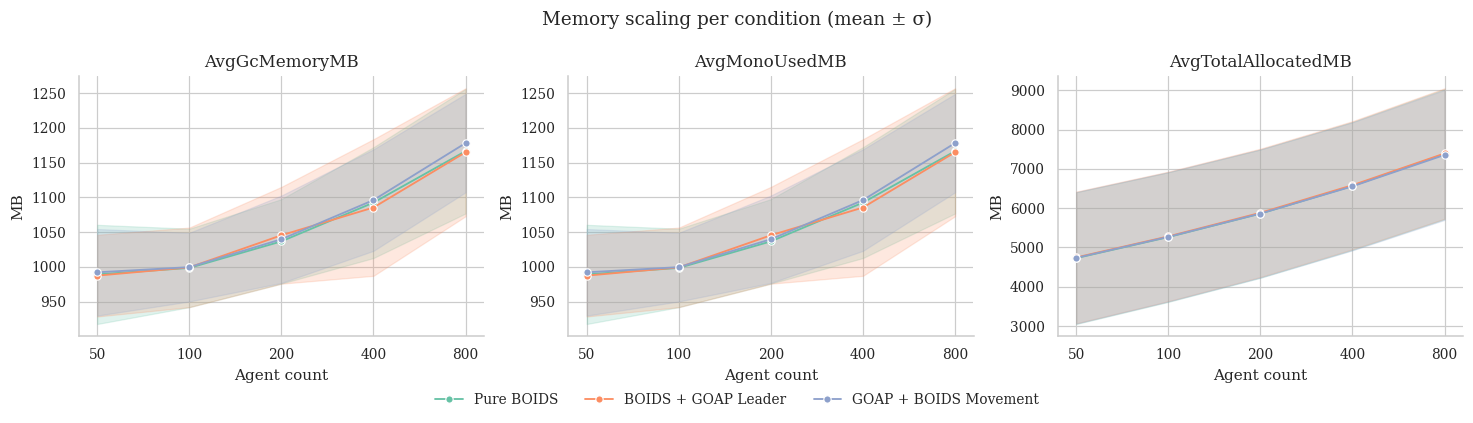

                                 AvgGcMemoryMB                 AvgMonoUsedMB  \
                                        median     q25     q75        median   
Condition             AgentCount                                               
PureBOIDS             50                 985.6   937.9  1035.5         985.6   
                      100                984.2   957.3  1046.5         984.2   
                      200               1028.3   991.1  1094.2        1028.3   
                      400               1092.8  1033.4  1144.2        1092.8   
                      800               1158.8  1091.3  1244.7        1158.8   
BOIDSWithGOAPLeader   50                 997.0   941.9  1041.7         997.0   
                      100               1013.0   950.1  1037.7        1013.0   
                      200               1040.2   989.6  1100.2        1040.2   
                      400               1068.4  1035.6  1147.3        1068.4   
                      800               

In [20]:
# Phase D - Memory scaling. Conditional: only runs if PerformanceProfiler.cs has
# been updated to log GcMemoryMB / MonoUsedMB / TotalAllocatedMB and a fresh batch
# has been recorded. Older batches that pre-date the schema change are gracefully
# skipped.

MEMORY_COLS = ['AvgGcMemoryMB', 'AvgMonoUsedMB', 'AvgTotalAllocatedMB']
have_memory = all(col in trials.columns for col in MEMORY_COLS)

if not have_memory:
    print(f'Skipping memory scaling cell — TrialSummary CSV is missing one or more of '
          f'{MEMORY_COLS}. Re-run a batch on post-Phase-D PerformanceProfiler to populate.')
else:
    fig, axes = plt.subplots(1, len(MEMORY_COLS),
                              figsize=(4.5 * len(MEMORY_COLS), 3.6),
                              squeeze=False)
    for ax, col in zip(axes[0], MEMORY_COLS):
        sns.lineplot(data=trials, x='AgentCount', y=col,
                     hue='Condition', hue_order=CONDITION_ORDER, palette=PALETTE,
                     marker='o', errorbar='sd', ax=ax)
        ax.set_xscale('log', base=2)
        ax.set_xticks(sorted(trials['AgentCount'].unique()))
        ax.set_xticklabels(sorted(trials['AgentCount'].unique()))
        ax.set_title(col)
        ax.set_xlabel('Agent count'); ax.set_ylabel('MB')
        leg = ax.get_legend()
        if leg is not None: leg.remove()
    handles, labels = axes[0, -1].get_legend_handles_labels()
    fig.legend(handles, [LABEL_MAP.get(l, l) for l in labels],
               loc='lower center', ncol=len(labels),
               bbox_to_anchor=(0.5, -0.05), frameon=False)
    fig.suptitle('Memory scaling per condition (mean ± σ)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'7_memory_scaling_{TS}.png', dpi=300, bbox_inches='tight')
    plt.show()

    mem_summary = (trials.groupby(['Condition', 'AgentCount'], observed=True)[MEMORY_COLS]
                          .agg(['median', q25, q75]).round(1))
    mem_summary.to_csv(FIG_DIR / f'memory_summary_{TS}.csv')
    print(mem_summary)
